<a id="seccion-0"></a>
# Proyecto Final Equipo 12: NYC TLC Yellow Taxi Trip Records

**Materia:** Análisis de grandes volúmenes de datos (Gpo 10)  
**Institución:** Tecnológico de Monterrey, Posgrados  
**Equipo 12:**

- Carlos Eduardo Vega Campos (A01797803)
- Marco Emilio Jiménez Jiménez (A01797948)
- Martha Alicia Villalobos Facundo (A01840063)
- Jonathan Javier Monsalve Giraldo (A01840272)

**Profesores:** Dr. Iván Olmos Pineda, Luis Daniel Mendoza  
**Fecha:** 28 de junio de 2026  
**Dataset:** NYC TLC Yellow Taxi Trip Records 2024-2025

**Enlaces de entrega:**

- Video: pendiente de pegar enlace.
- Backup de dataset: pendiente de pegar enlace.

## Índice

0. [Portada, objetivo y configuración](#seccion-0)
1. [Lectura del dataset original](#seccion-1)
2. [Caracterización del dataset](#seccion-2)
3. [Limpieza y variables de caracterización de la población](#seccion-3)
4. [Estrategia de muestreo y construcción de la muestra M](#seccion-4)
5. [Preparación de conjuntos de entrenamiento y prueba](#seccion-5)
6. [Selección de métricas para medir calidad](#seccion-6)
7. [Experimentación: entrenamiento y selección de modelos](#seccion-7)
8. [Validación cruzada de modelos ganadores](#seccion-8)
9. [Presentación de resultados](#seccion-9)
10. [Discusión y conclusiones](#seccion-10)
11. [Declaración de uso de inteligencia artificial](#seccion-11)


## Objetivo del proyecto

El objetivo de este proyecto es implementar y documentar, de principio a fin, un proceso de aprendizaje aplicado a grandes volúmenes de datos para NYC TLC Yellow Taxi 2024-2025. El entregable muestra cómo se pasa de los datos originales a una muestra representativa, cómo se preparan los conjuntos de entrenamiento y prueba, cómo se seleccionan modelos de aprendizaje y cómo se presentan resultados con evidencia cuantitativa y visual.

El problema es relevante porque los viajes de taxi amarillo concentran decisiones operativas y económicas a gran escala: millones de trayectos, zonas con patrones de demanda distintos, horarios pico, viajes a aeropuerto, pagos con taxímetro y viajes Flex Fare solicitados por aplicación. En ese contexto, estimar la tarifa base ayuda a detectar viajes difíciles de explicar, auditar diferencias entre regímenes tarifarios y medir qué tanto las variables operativas explican el cobro. A la vez, segmentar viajes en arquetipos permite resumir millones de registros en perfiles útiles para planeación, análisis de demanda, comparación de zonas y comunicación de hallazgos a personas no técnicas.

El proyecto responde dos preguntas de aprendizaje complementarias:

- La primera es supervisada: ¿qué tan bien se puede estimar la tarifa base de un viaje a partir de sus características operativas?
- La segunda es no supervisada: ¿existen arquetipos operativos estables en millones de viajes Yellow Taxi?

Para responderlas, este documento reproducible descarga y carga los datos originales, caracteriza el dataset, aplica la limpieza acordada en etapas previas, construye variables de caracterización poblacional, extrae la muestra estratificada M, prepara train/test, entrena y compara modelos supervisados y no supervisados, valida la estabilidad de los ganadores con validación cruzada de 5 folds y genera visualizaciones para discutir resultados, limitaciones y trabajo futuro.


## 0. Configuración del entorno

Esta celda instala o verifica dependencias, inicializa Spark y deja disponibles las librerías usadas por el resto del análisis. Es idempotente: si las dependencias ya existen, no se reinstalan.


In [ ]:
# Librerías estándar
import importlib.util
import subprocess
import sys
import time
import urllib.request
from functools import reduce
from pathlib import Path


def ensure_package(package_name, import_name=None):
    import_name = import_name or package_name

    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])


IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # En Colab, Java suele estar disponible. Esta verificación deja explícito el requisito.
    java_check = subprocess.run(
        ["bash", "-lc", "java -version"], capture_output=True, text=True
    )

    if java_check.returncode != 0:
        subprocess.check_call(["apt-get", "update"])
        subprocess.check_call(["apt-get", "install", "-y", "openjdk-11-jdk-headless"])

ensure_package("findspark")
ensure_package("pyspark")
ensure_package("pandas")
ensure_package("numpy")
ensure_package("matplotlib")
ensure_package("seaborn")

# Librerías externas
import findspark

findspark.init()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from pyspark import StorageLevel
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.clustering import GaussianMixture, KMeans
from pyspark.ml.evaluation import ClusteringEvaluator, RegressionEvaluator
from pyspark.ml.feature import (
    OneHotEncoder,
    StandardScaler,
    StringIndexer,
    VectorAssembler,
)
from pyspark.ml.functions import vector_to_array
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.stat import Correlation
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

DATA_DIR = Path("data") / "raw"

spark = (
    SparkSession.builder.appName("Proyecto_Final_Equipo12")
    .master("local[*]")
    .config("spark.driver.memory", "8g")
    .config("spark.driver.maxResultSize", "4g")
    .config("spark.sql.debug.maxToStringFields", "100")
    .getOrCreate()
)

# En la entrega final se ocultan logs WARN/INFO de Spark para no contaminar las salidas.
spark.sparkContext.setLogLevel("ERROR")

print(f"Entorno Colab: {IN_COLAB}")
print(f"Ruta de datos: {DATA_DIR}")
print(f"Versión de Spark: {spark.version}")


Entorno Colab: False
Ruta de datos: data/raw
Versión de Spark: 4.1.1


**Lectura de la sección.** La ejecución quedó configurada en entorno local con Spark 4.1.1 y ruta de datos `data/raw`. Esta configuración conserva el enfoque técnico validado en entregas anteriores: procesar el volumen completo con Spark, mantener la descarga y carga dentro del flujo reproducible y evitar depender de archivos intermedios manuales. La conclusión que se arrastra de esas entregas es que el problema requiere una herramienta distribuida y una cadena controlada de preparación antes de cualquier muestreo o modelado. El ajuste agregado a los logs solo reduce advertencias repetitivas de ejecución y no cambia los datos ni la metodología.


<a id="seccion-1"></a>
# 1. Lectura del dataset original

La primera etapa descarga los 24 archivos Parquet mensuales de 2024 y 2025, más el catálogo `taxi_zone_lookup.csv`. La descarga es idempotente y deja los datos originales en `data/raw` dentro del proyecto.


In [ ]:
CDN_BASE = "https://d37ci6vzurychx.cloudfront.net"
YEARS = (2024, 2025)


def fetch(url, target):
    target = Path(target)

    if target.exists():
        return "skip"

    target.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(url, target)

    return "downloaded"


download_log = []
for year in YEARS:
    for month in range(1, 13):
        filename = f"yellow_tripdata_{year}-{month:02d}.parquet"
        status = fetch(f"{CDN_BASE}/trip-data/{filename}", DATA_DIR / filename)
        download_log.append((filename, status))

zones_status = fetch(
    f"{CDN_BASE}/misc/taxi_zone_lookup.csv", DATA_DIR / "taxi_zone_lookup.csv"
)

print("Archivos Parquet revisados:", len(download_log))
print(
    "Archivos descargados:",
    sum(1 for _, status in download_log if status == "downloaded"),
)
print("Catálogo de zonas:", zones_status)


Archivos Parquet revisados: 24
Archivos descargados: 0
Catálogo de zonas: skip


La siguiente celda carga los Parquet originales con `mergeSchema=True`, porque `cbd_congestion_fee` aparece en archivos de 2025 pero no en 2024. Después aplica el downcast validado en Etapa 1 para reducir presión de memoria sin cambiar el contenido analítico.


In [3]:
parquet_paths = sorted(str(path) for path in DATA_DIR.glob("yellow_tripdata_*.parquet"))
assert (
    len(parquet_paths) == 24
), f"Se esperaban 24 archivos Parquet, se encontraron {len(parquet_paths)}"

df_native = spark.read.option("mergeSchema", "true").parquet(*parquet_paths)
zones = (
    spark.read.option("header", True)
    .option("inferSchema", True)
    .csv(str(DATA_DIR / "taxi_zone_lookup.csv"))
)

df_raw = df_native.selectExpr(
    "cast(VendorID as tinyint) VendorID",
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "cast(passenger_count as tinyint) passenger_count",
    "cast(trip_distance as float) trip_distance",
    "cast(RatecodeID as tinyint) RatecodeID",
    "store_and_fwd_flag",
    "cast(PULocationID as smallint) PULocationID",
    "cast(DOLocationID as smallint) DOLocationID",
    "cast(payment_type as tinyint) payment_type",
    "cast(fare_amount as float) fare_amount",
    "cast(extra as float) extra",
    "cast(mta_tax as float) mta_tax",
    "cast(tip_amount as float) tip_amount",
    "cast(tolls_amount as float) tolls_amount",
    "cast(improvement_surcharge as float) improvement_surcharge",
    "cast(total_amount as float) total_amount",
    "cast(congestion_surcharge as float) congestion_surcharge",
    "cast(Airport_fee as float) Airport_fee",
    "cast(cbd_congestion_fee as float) cbd_congestion_fee",
)

n_raw = df_raw.count()
print(f"Filas crudas: {n_raw:,}")
print(f"Particiones de df_raw: {df_raw.rdd.getNumPartitions():,}")
print("Columnas:", df_raw.columns)

assert n_raw == 89_892_322, "El conteo crudo no coincide con la referencia de Etapa 1"


Filas crudas: 89,892,322
Particiones de df_raw: 22
Columnas: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']


## Diccionario de variables del dataset original

La base principal proviene de los archivos mensuales `yellow_tripdata_YYYY-MM.parquet` de NYC TLC. Cada fila representa un viaje Yellow Taxi y combina información temporal, geográfica, operativa y monetaria. El catálogo `taxi_zone_lookup.csv` complementa las zonas de pickup y dropoff con nombres de borough, zona y service zone.

| Variable | Tipo en el análisis | Descripción | Uso en este proyecto |
|---|---:|---|---|
| `VendorID` | Categórica | Proveedor que registró el viaje. | Auditoría descriptiva y control de origen del registro. |
| `tpep_pickup_datetime` | Timestamp | Fecha y hora de inicio del viaje. | Filtros temporales, mes, hora, día de semana, periodo CBD y duración. |
| `tpep_dropoff_datetime` | Timestamp | Fecha y hora de fin del viaje. | Cálculo de `trip_duration_min` y filtros de duración plausible. |
| `passenger_count` | Numérica discreta | Número de pasajeros reportado. | Feature supervisada y no supervisada después de imputación operativa. |
| `trip_distance` | Numérica | Distancia del viaje en millas según taxímetro o registro TLC. | Variable central para limpieza, muestreo, regresión y clustering. |
| `RatecodeID` | Categórica | Código de tarifa aplicado al viaje. | Feature supervisada y no supervisada; también distingue reglas tarifarias. |
| `store_and_fwd_flag` | Categórica | Indica si el viaje se almacenó antes de enviarse al proveedor. | Variable de calidad e imputación para registros Flex Fare. |
| `PULocationID` | Categórica geográfica | Zona TLC donde inició el viaje. | Construcción de macrozonas y estratos de muestreo. |
| `DOLocationID` | Categórica geográfica | Zona TLC donde terminó el viaje. | Caracterización geográfica y posibles análisis posteriores. |
| `payment_type` | Categórica | Método de pago registrado. | Agrupación en crédito, efectivo, Flex y otros; análisis de propinas. |
| `fare_amount` | Numérica monetaria | Tarifa base del viaje. | Variable objetivo del modelo supervisado. |
| `extra` | Numérica monetaria | Cargos extra asociados al viaje. | Excluida del modelo para evitar fuga de información. |
| `mta_tax` | Numérica monetaria | Impuesto MTA. | Excluida del modelo para evitar fuga de información. |
| `tip_amount` | Numérica monetaria | Propina registrada, principalmente en pagos con tarjeta. | EDA; excluida del modelo por ser posterior al cobro. |
| `tolls_amount` | Numérica monetaria | Peajes cobrados. | EDA; excluida del modelo para evitar fuga de información. |
| `improvement_surcharge` | Numérica monetaria | Recargo de mejora regulatorio. | Excluida del modelo para evitar fuga de información. |
| `total_amount` | Numérica monetaria | Cobro total al pasajero, excluyendo propinas en efectivo. | Validación de calidad; excluida del modelo por fuga directa. |
| `congestion_surcharge` | Numérica monetaria | Recargo por congestión aplicable. | Imputación operativa y EDA; excluida del modelo supervisado. |
| `Airport_fee` | Numérica monetaria | Recargo de aeropuerto. | Imputación operativa y EDA; excluida del modelo supervisado. |
| `cbd_congestion_fee` | Numérica monetaria | Cargo CBD, presente desde 2025. | Variable importante para compatibilidad 2024-2025; se imputa según periodo. |

Dominios relevantes para la interpretación:

| Variable | Códigos usados en el análisis |
|---|---|
| `RatecodeID` | 1 Standard, 2 JFK, 3 Newark, 4 Nassau/Westchester, 5 negotiated fare, 6 group ride, 99 código sintético usado para Flex Fare nulo. |
| `payment_type` | 0 Flex Fare, 1 crédito, 2 efectivo, 3 sin cargo, 4 disputa, 5 desconocido, otros valores como categoría residual. |
| `store_and_fwd_flag` | `N` no almacenado, `Y` almacenado, `F` código sintético para Flex Fare nulo. |
| `PULocationID`, `DOLocationID` | IDs TLC enlazados al catálogo de zonas. Las zonas 264 y 265 se tratan como desconocidas o placeholder. |

Variables derivadas principales que se construyen más adelante:

| Variable derivada | Origen | Propósito |
|---|---|---|
| `trip_duration_min` | Diferencia entre dropoff y pickup. | Feature de modelado y filtro de viajes temporalmente plausibles. |
| `pu_macro_zone` | `PULocationID` + catálogo de zonas. | Estratificación, modelado e interpretación geográfica. |
| `payment_group` | `payment_type`. | Estratificación y separación de crédito, efectivo, Flex y otros. |
| `day_hour_bucket` | Hora y día de pickup. | Estratificación y patrón temporal de operación. |
| `trip_distance_bin` | `trip_distance`. | Estratificación por viajes cortos, medios y largos. |
| `is_flex_fare` | `payment_type == 0`. | Bandera para separar el régimen Flex Fare en limpieza, modelado y lectura de resultados. |
| `cbd_period_flag` | Fecha de pickup. | Identifica viajes antes o después del inicio del cargo CBD. |
| `stratum_id` | Macro zona, pago, horario y distancia. | Llave de muestreo estratificado y particiones balanceadas. |


**Lectura de la sección.** La base cruda consolidada contiene 89,892,322 viajes en 22 particiones y conserva la columna `cbd_congestion_fee`, por lo que la carga cubre el volumen requerido y mantiene las variables necesarias para estudiar cargos, zonas, tiempos y características operativas del viaje. La descarga revisó 24 archivos Parquet y el catálogo de zonas, lo que confirma que el análisis es reproducible desde la fuente pública usada por el equipo.


<a id="seccion-2"></a>
# 2. Caracterización del dataset

Antes de limpiar y modelar, se caracterizan distribuciones, nulos, cardinalidades, patrones temporales, correlaciones y visualizaciones descriptivas. Esta sección replica los hallazgos centrales de Etapa 1.


La siguiente celda calcula resumen estadístico, percentiles aproximados, conteo de nulos y cardinalidades de variables enumeradas.


In [ ]:
continuous_cols = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount",
    "congestion_surcharge",
    "Airport_fee",
    "cbd_congestion_fee",
]

summary_sdf = df_raw.select(continuous_cols).summary(
    "count", "mean", "stddev", "min", "max"
)
summary_pdf = summary_sdf.toPandas().set_index("summary").T
summary_pdf.index.name = "variable"
display(summary_pdf)

quantile_cols = ["fare_amount", "trip_distance", "tip_amount", "total_amount"]
probabilities = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
quantile_values = df_raw.approxQuantile(quantile_cols, probabilities, 0.01)
quantile_pdf = pd.DataFrame(
    {col_name: values for col_name, values in zip(quantile_cols, quantile_values)},
    index=[f"p{int(p * 100)}" for p in probabilities],
)
display(quantile_pdf)

counts_pdf = df_raw.summary("count").toPandas().drop(columns=["summary"]).T
counts_pdf.columns = ["non_null"]
counts_pdf["non_null"] = counts_pdf["non_null"].astype(int)
ts_cols = [
    c
    for c, t in df_raw.dtypes
    if t.startswith("timestamp") and c not in counts_pdf.index
]

if ts_cols:
    ts_row = df_raw.agg(*[F.count(c).alias(c) for c in ts_cols]).first()
    for c in ts_cols:
        counts_pdf.loc[c] = [ts_row[c]]

counts_pdf = counts_pdf.reindex(df_raw.columns)
counts_pdf["nulos"] = n_raw - counts_pdf["non_null"]
counts_pdf["pct_nulos"] = (counts_pdf["nulos"] / n_raw * 100).round(2)
counts_pdf.index.name = "columna"
display(counts_pdf[["nulos", "pct_nulos"]])

enum_cols = ["VendorID", "RatecodeID", "payment_type", "store_and_fwd_flag"]
for col_name in enum_cols:
    print(f"\nCardinalidad y frecuencias para {col_name}")
    df_raw.groupBy(col_name).count().orderBy(col_name).show(30, truncate=False)


summary,count,mean,stddev,min,max
variable,,,,,
passenger_count,74189196,1.3147025612732075,0.7739282157205499,0,9
trip_distance,89892322,5.987921635632805,555.9173851671442,0.0,398608.62
fare_amount,89892322,18.808269948301515,117.28427802441267,-2261.2,863372.1
extra,89892322,1.2658486959542317,1.8225766495787001,-17.39,133.6
mta_tax,89892322,0.4786429412723655,0.569083689401905,-21.74,5243.38
tip_amount,89892322,3.055505823537555,4.030595787460732,-333.33,999.99
tolls_amount,89892322,0.5275469803959015,2.1767747851875714,-148.17,1702.88
improvement_surcharge,89892322,0.9561168077330069,0.2706889786074781,-1.0,2.5
total_amount,89892322,27.33198830099859,118.10550131865723,-2265.45,863380.4


,fare_amount,trip_distance,tip_amount,total_amount
p25,9.300000,1.020,0.00000,15.700000
p50,14.200000,1.800,2.38000,21.059999
p75,22.600000,3.490,4.07000,30.450001
p90,39.400002,8.550,6.70000,52.000000
p95,58.299999,12.670,10.93000,80.589996
p99,863372.125000,398608.625,999.98999,863380.375000


,nulos,pct_nulos
columna,,
VendorID,0,0.00
tpep_pickup_datetime,0,0.00
tpep_dropoff_datetime,0,0.00
passenger_count,15703126,17.47
trip_distance,0,0.00
RatecodeID,15703126,17.47
store_and_fwd_flag,15703126,17.47
PULocationID,0,0.00
DOLocationID,0,0.00



Cardinalidad y frecuencias para VendorID
+--------+--------+
|VendorID|count   |
+--------+--------+
|1       |19302791|
|2       |70027349|
|6       |26051   |
|7       |536131  |
+--------+--------+


Cardinalidad y frecuencias para RatecodeID
+----------+--------+
|RatecodeID|count   |
+----------+--------+
|NULL      |15703126|
|1         |68944012|
|2         |2704804 |
|3         |280643  |
|4         |217870  |
|5         |770369  |
|6         |127     |
|99        |1271371 |
+----------+--------+


Cardinalidad y frecuencias para payment_type
+------------+--------+
|payment_type|count   |
+------------+--------+
|0           |15703126|
|1           |61506159|
|2           |10194433|
|3           |599890  |
|4           |1888707 |
|5           |7       |
+------------+--------+


Cardinalidad y frecuencias para store_and_fwd_flag
+------------------+--------+
|store_and_fwd_flag|count   |
+------------------+--------+
|NULL              |15703126|
|N                 |73902809|

La siguiente celda resume patrones temporales por mes, hora y día de semana. El heatmap permite ver picos y valles de demanda.


,pickup_month,count
0,2002-12,11
1,2007-12,1
2,2008-12,11
3,2009-01,24
4,2023-12,10
5,2024-01,2964617
6,2024-02,3007533
7,2024-03,3582611
8,2024-04,3514295
9,2024-05,3723843


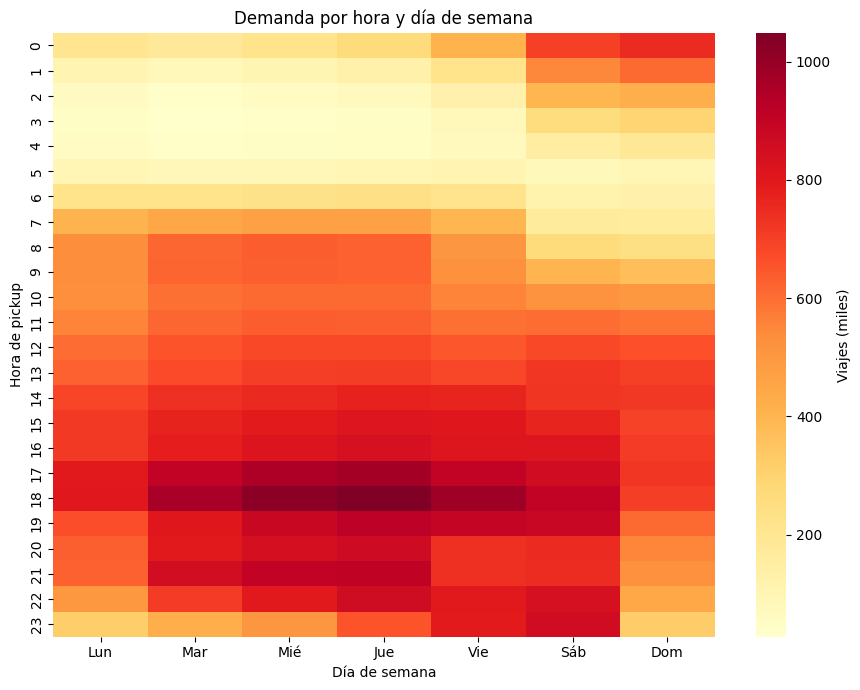

In [5]:
temporal_counts = (
    df_raw.withColumn("pickup_hour", F.hour("tpep_pickup_datetime"))
    .withColumn("dow", F.dayofweek("tpep_pickup_datetime"))
    .withColumn("pickup_month", F.date_format("tpep_pickup_datetime", "yyyy-MM"))
)

hour_dow_pdf = temporal_counts.groupBy("pickup_hour", "dow").count().toPandas()

month_pdf = (
    temporal_counts.groupBy("pickup_month").count().orderBy("pickup_month").toPandas()
)

display(month_pdf)

heatmap_data = hour_dow_pdf.pivot(
    index="pickup_hour", columns="dow", values="count"
).sort_index()
heatmap_data = heatmap_data.rename(
    columns={1: "Dom", 2: "Lun", 3: "Mar", 4: "Mié", 5: "Jue", 6: "Vie", 7: "Sáb"}
)
heatmap_data = heatmap_data[["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]]

plt.figure(figsize=(9, 7))
sns.heatmap(heatmap_data / 1000, cmap="YlOrRd", cbar_kws={"label": "Viajes (miles)"})
plt.title("Demanda por hora y día de semana")
plt.xlabel("Día de semana")
plt.ylabel("Hora de pickup")
plt.tight_layout()
plt.show()


**Interpretación del gráfico.** La serie mensual confirma que el volumen principal corresponde a 2024-2025 y que los registros fuera de ese rango son residuales. El mapa de calor muestra cómo cambia la demanda por hora entre días laborales y fin de semana, con patrones horarios diferenciados que justifican conservar variables temporales en la caracterización. Esta vista también respalda que los filtros temporales posteriores eliminen fechas anómalas sin afectar la estructura central del dataset.


La siguiente celda calcula una matriz de correlación de Pearson sobre datos crudos. Sirve para documentar la distorsión causada por outliers antes de la limpieza.


,passenger_count,trip_distance,trip_duration_min,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
passenger_count,1.00,0.00,0.02,0.01,-0.06,-0.01,0.03,0.03,0.01,0.01,-0.00,0.03,0.02
trip_distance,0.00,1.00,0.03,0.01,0.01,-0.00,0.03,0.04,-0.01,0.01,-0.02,0.04,-0.01
trip_duration_min,0.02,0.03,1.00,0.04,0.04,-0.00,0.20,0.20,-0.07,0.05,-0.10,0.18,-0.01
fare_amount,0.01,0.01,0.04,1.00,0.02,0.00,0.07,0.07,0.03,1.00,-0.01,0.07,0.01
extra,-0.06,0.01,0.04,0.02,1.00,0.03,0.21,0.22,0.23,0.04,0.15,0.30,0.12
mta_tax,-0.01,-0.00,-0.00,0.00,0.03,1.00,0.01,-0.01,0.14,0.01,0.12,0.02,0.07
tip_amount,0.03,0.03,0.20,0.07,0.21,0.01,1.00,0.45,0.17,0.11,0.04,0.41,0.09
tolls_amount,0.03,0.04,0.20,0.07,0.22,-0.01,0.45,1.00,0.06,0.10,-0.07,0.45,0.01
improvement_surcharge,0.01,-0.01,-0.07,0.03,0.23,0.14,0.17,0.06,1.00,0.04,0.74,0.15,0.47
total_amount,0.01,0.01,0.05,1.00,0.04,0.01,0.11,0.10,0.04,1.00,0.00,0.09,0.02


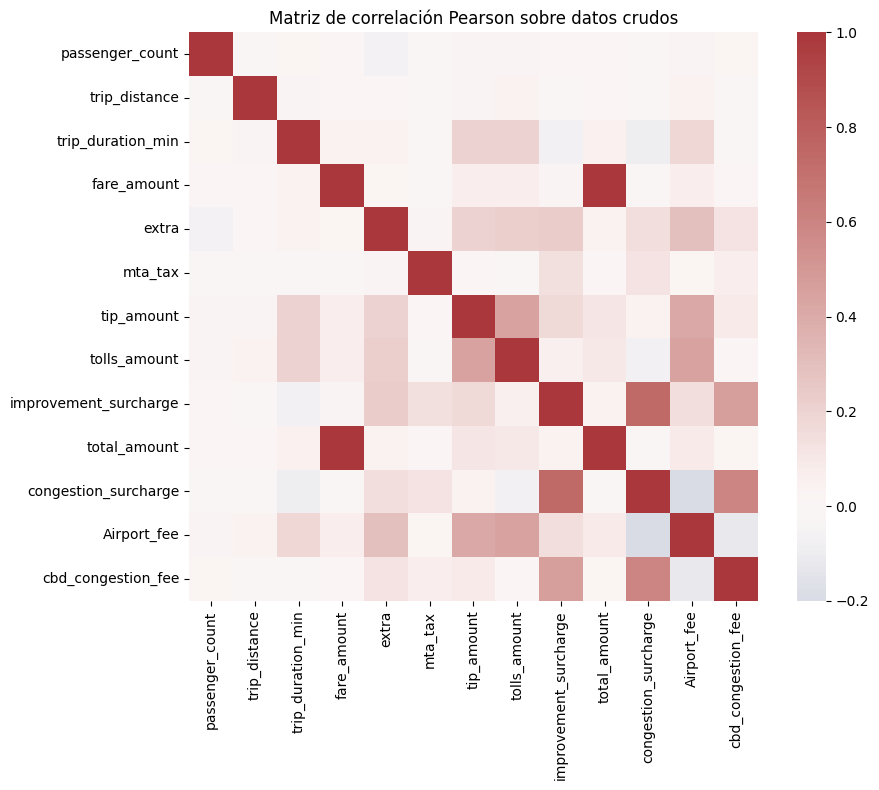

In [6]:
df_corr = df_raw.withColumn(
    "trip_duration_min",
    (
        F.unix_timestamp("tpep_dropoff_datetime")
        - F.unix_timestamp("tpep_pickup_datetime")
    )
    / F.lit(60.0),
)

corr_cols = [
    "passenger_count",
    "trip_distance",
    "trip_duration_min",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount",
    "congestion_surcharge",
    "Airport_fee",
    "cbd_congestion_fee",
]

assembler = VectorAssembler(
    inputCols=corr_cols, outputCol="features", handleInvalid="skip"
)
df_assembled = assembler.transform(df_corr).select("features")
corr_matrix = Correlation.corr(df_assembled, "features", "pearson").head()[0].toArray()
corr_pdf = pd.DataFrame(corr_matrix, index=corr_cols, columns=corr_cols).round(2)
display(corr_pdf)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_pdf, cmap="vlag", center=0, square=True)
plt.title("Matriz de correlación Pearson sobre datos crudos")
plt.tight_layout()
plt.show()


**Interpretación del gráfico.** La matriz muestra que las variables monetarias relacionadas con el cobro total se mueven juntas, pero la relación cruda entre distancia y tarifa aparece artificialmente baja. Esto no contradice la lógica de negocio; indica que antes de limpiar existen outliers, tarifas especiales y registros inconsistentes que ocultan la relación esperada entre recorrido y cobro.


La siguiente gráfica revisa la relación cruda entre distancia del viaje y tarifa base.


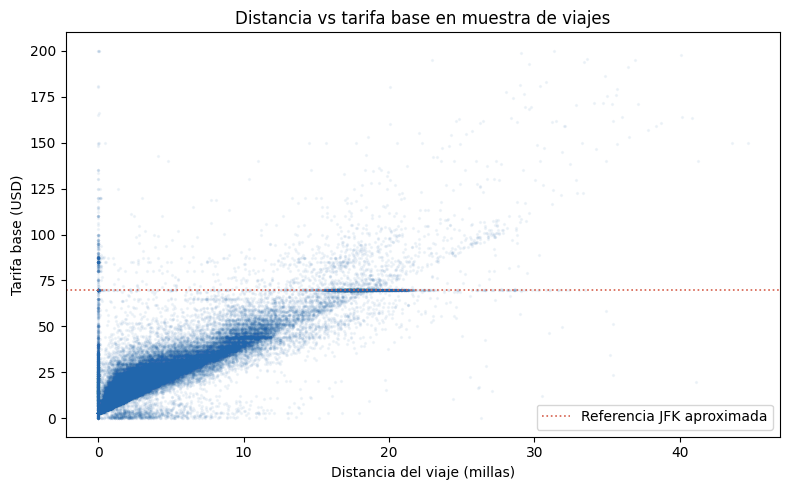

In [7]:
# Scatter distancia vs tarifa.
scatter_pdf = (
    df_raw.select("trip_distance", "fare_amount")
    .filter(
        (F.col("trip_distance") >= 0)
        & (F.col("trip_distance") <= 50)
        & (F.col("fare_amount") >= 0)
        & (F.col("fare_amount") <= 200)
    )
    .sample(fraction=0.002, seed=42)
    .limit(100_000)
    .toPandas()
)

plt.figure(figsize=(8, 5))
plt.scatter(
    scatter_pdf["trip_distance"],
    scatter_pdf["fare_amount"],
    s=2,
    alpha=0.05,
    color="#2166ac",
)
plt.axhline(
    70, color="#d6604d", linestyle=":", linewidth=1.2, label="Referencia JFK aproximada"
)
plt.xlabel("Distancia del viaje (millas)")
plt.ylabel("Tarifa base (USD)")
plt.title("Distancia vs tarifa base en muestra de viajes")
plt.legend()
plt.tight_layout()
plt.show()


**Interpretación del gráfico.** La mayor parte de los viajes se concentra en distancias cortas y tarifas bajas o medias, pero la relación no es una línea limpia. Se observan bandas de tarifa y dispersión creciente conforme aumenta la distancia, incluida una referencia cercana a tarifas planas de aeropuerto. Esto refuerza que la tarifa no depende solo de millas recorridas: también intervienen reglas tarifarias, zonas y tipos de viaje que deben conservarse como variables de modelado.


La siguiente gráfica compara la distribución de propinas por método de pago.


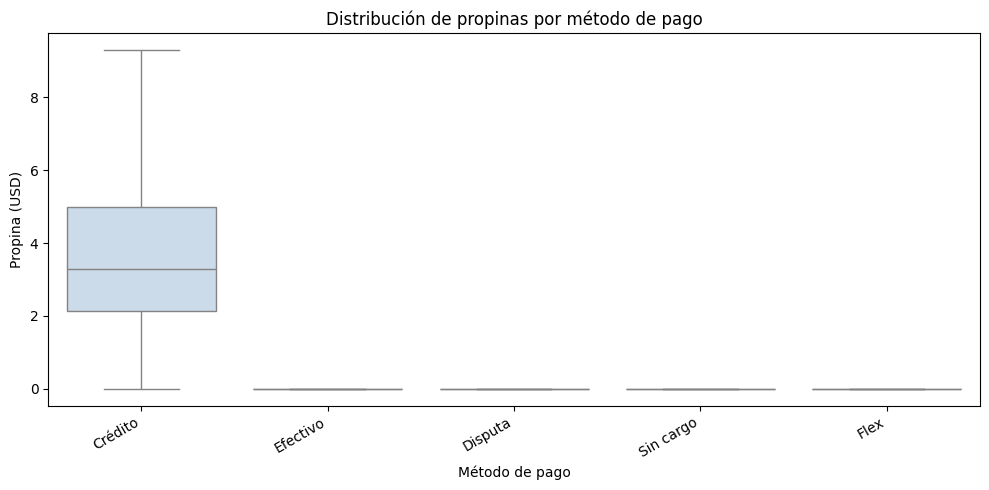

In [8]:
# Boxplots de propina por método de pago.
tip_pdf = (
    df_raw.select("payment_type", "tip_amount")
    .filter((F.col("tip_amount") >= 0) & (F.col("tip_amount") <= 100))
    .sample(fraction=0.002, seed=42)
    .limit(200_000)
    .toPandas()
)

payment_labels = {
    0: "Flex",
    1: "Crédito",
    2: "Efectivo",
    3: "Sin cargo",
    4: "Disputa",
    5: "Desconocido",
    6: "Anulado",
}
tip_pdf["payment_label"] = tip_pdf["payment_type"].map(payment_labels).fillna("Otro")

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=tip_pdf, x="payment_label", y="tip_amount", showfliers=False, color="#c6dbef"
)
plt.xlabel("Método de pago")
plt.ylabel("Propina (USD)")
plt.title("Distribución de propinas por método de pago")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


**Interpretación del gráfico.** Las propinas no se distribuyen igual entre métodos de pago. En pagos con tarjeta aparece una dispersión más visible, mientras que en efectivo y otros métodos la propina registrada tiende a concentrarse cerca de cero o a depender del mecanismo de captura. Esta diferencia confirma que `tip_amount` no debe tratarse como una variable neutral para explicar la tarifa base y respalda excluir variables monetarias posteriores al cobro para evitar fuga de información.


La siguiente gráfica resume el porcentaje de valores nulos por columna.


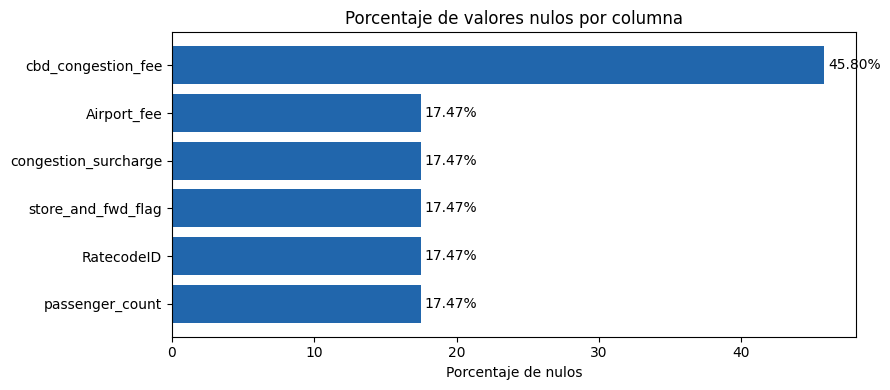

In [ ]:
# Porcentaje de nulos por columna.
nulls_plot = counts_pdf[counts_pdf["pct_nulos"] > 0][["pct_nulos"]].sort_values(
    "pct_nulos", ascending=True
)
plt.figure(figsize=(9, max(4, len(nulls_plot) * 0.45)))
plt.barh(nulls_plot.index, nulls_plot["pct_nulos"], color="#2166ac")

for y_pos, value in enumerate(nulls_plot["pct_nulos"]):
    plt.text(value + 0.3, y_pos, f"{value:.2f}%", va="center")

plt.xlabel("Porcentaje de nulos")
plt.title("Porcentaje de valores nulos por columna")
plt.tight_layout()
plt.show()


**Interpretación del gráfico.** Los nulos no están distribuidos de forma aleatoria en todas las columnas. `cbd_congestion_fee` concentra la mayor ausencia, con 45.80%, mientras `passenger_count`, `RatecodeID`, `store_and_fwd_flag`, `congestion_surcharge` y `Airport_fee` comparten 17.47% de nulos. Como las columnas principales de tiempo, ubicación, distancia y montos base están completas, la decisión razonable no es eliminar esos registros, sino imputar de forma explícita las variables operativas faltantes y documentar los códigos sintéticos usados.


**Lectura de la sección.** El EDA confirma que el dataset crudo necesita depuración antes de modelar: aparecen fechas fuera de 2024-2025, montos negativos, viajes de distancia cero con tarifa positiva y valores extremos de distancia y tarifa. La correlación cruda entre distancia y tarifa no refleja la relación operativa esperada porque está contaminada por esos casos atípicos y por componentes de cobro que no siguen la lógica de viaje medido. La distribución de propinas también muestra dependencia fuerte del método de pago, por lo que no debe interpretarse como una variable neutral de comportamiento si no se controla por segmento de pago.


<a id="seccion-3"></a>
# 3. Limpieza y variables de caracterización de la población

Esta sección aplica la limpieza definida en Etapa 2. En esa entrega se concluyó que la base cruda contiene registros incompatibles con una lectura operativa del servicio, como fechas fuera del periodo declarado, montos negativos, distancias extremas y viajes con distancia cero pero tarifa positiva. Por eso, aquí los filtros destructivos eliminan registros físicamente imposibles o fuera del alcance del estudio. Las imputaciones no intentan recuperar telemetría real: crean valores operativos y códigos sintéticos para preservar registros útiles y permitir muestreo/modelado sin mezclar nulos con categorías reales.


## 3.1 Tabla de cambios de limpieza y preparación

Antes de aplicar código, la siguiente tabla resume qué se corrige, qué acción se toma y por qué. La separación es importante: los filtros eliminan registros fuera del alcance o físicamente inconsistentes; las imputaciones conservan registros válidos con campos ausentes; las variables derivadas preparan la población para muestreo y modelado.

| Grupo | Variable o condición | Acción aplicada | Justificación |
|---|---|---|---|
| Filtro destructivo | `tpep_pickup_datetime < 2024-01-01` | Excluir registro. | Fuera del periodo declarado 2024-2025. |
| Filtro destructivo | `tpep_pickup_datetime >= 2026-01-01` | Excluir registro. | 2026 se reserva para validación temporal futura, no para entrenamiento actual. |
| Filtro destructivo | `trip_distance < 0` o `trip_distance > 200` | Excluir registro. | Distancias negativas o extremadamente altas no son plausibles para operación Yellow Taxi. |
| Filtro destructivo | `fare_amount < 0` o `fare_amount > 1000` | Excluir registro. | Tarifas base negativas o extremas distorsionan el aprendizaje supervisado. |
| Filtro destructivo | `total_amount < 0` o `total_amount > 1200` | Excluir registro. | Cobros totales fuera de rango operativo razonable. |
| Filtro destructivo | `trip_distance == 0` y `fare_amount > 0` | Excluir registro. | Viajes con tarifa positiva sin distancia registrada rompen la relación operativa distancia-tarifa. |
| Imputación operativa | `passenger_count` nulo o fuera de `[1, 6]` | Reemplazar por 1. | Conserva registros con conteo inválido sin introducir una categoría no operativa. |
| Imputación operativa | `cbd_congestion_fee` nulo o previo a 2025-01-05 | Reemplazar por 0.0. | El cargo CBD no aplica antes de su inicio y no debe quedar como nulo estructural. |
| Imputación operativa | `congestion_surcharge`, `Airport_fee` nulos | Reemplazar por 0.0. | Ausencia se interpreta como cargo no aplicado. |
| Imputación operativa | `RatecodeID` nulo | Reemplazar por 99. | Código sintético para distinguir Flex Fare sin inventar un ratecode oficial. |
| Imputación operativa | `store_and_fwd_flag` nulo | Reemplazar por `F`. | Código sintético para Flex Fare; no representa una lectura observada del taxímetro. |
| Variable derivada | `pu_macro_zone` | Clasificar pickup en airport, manhattan, outer_borough o unknown. | Reduce granularidad geográfica para muestreo e interpretación. |
| Variable derivada | `payment_group` | Agrupar método de pago en credit, cash, flex u other. | Permite separar regímenes de pago y proteger Flex Fare en muestreo. |
| Variable derivada | `day_hour_bucket` | Construir bloques de horario y día. | Resume patrones temporales sin usar 168 combinaciones hora-día. |
| Variable derivada | `trip_distance_bin` | Clasificar distancia en short, medium o long. | Protege viajes cortos, medios y largos en el muestreo estratificado. |
| Variable derivada | `stratum_id` | Concatenar macrozona, pago, horario y distancia. | Llave de los 240 estratos teóricos para construir la muestra M. |


La siguiente celda aplica filtros destructivos y muestra un diagnóstico por regla de exclusión.


In [10]:
filtros_exclusion = [
    ("date < 2024-01-01", F.col("tpep_pickup_datetime") < F.lit("2024-01-01")),
    ("date >= 2026-01-01", F.col("tpep_pickup_datetime") >= F.lit("2026-01-01")),
    ("trip_distance < 0", F.col("trip_distance") < 0),
    ("trip_distance > 200", F.col("trip_distance") > 200),
    ("fare_amount < 0", F.col("fare_amount") < 0),
    ("fare_amount > 1000", F.col("fare_amount") > 1000),
    ("total_amount < 0", F.col("total_amount") < 0),
    ("total_amount > 1200", F.col("total_amount") > 1200),
    (
        "distance=0 AND fare>0",
        (F.col("trip_distance") == 0) & (F.col("fare_amount") > 0),
    ),
]

exclusion_condition = reduce(
    lambda a, b: a | b, [condition for _, condition in filtros_exclusion]
)

df_filtered = df_raw.filter(~exclusion_condition)
n_filtered = df_filtered.count()
pct_removed = (n_raw - n_filtered) / n_raw * 100

print(f"Registros tras filtros destructivos: {n_filtered:,}")
print(f"Filas removidas: {n_raw - n_filtered:,} ({pct_removed:.2f}%)")
assert pct_removed < 15, "La pérdida por filtros supera el umbral de seguridad del 15%"

diagnostic_row = df_raw.agg(
    F.count("*").alias("total"),
    *[
        F.sum(condition.cast("int")).alias(label)
        for label, condition in filtros_exclusion
    ],
).first()

diagnostic_pdf = pd.DataFrame(
    [
        {
            "condicion": label,
            "filas_excluidas_individualmente": int(diagnostic_row[label] or 0),
            "pct_total": round((int(diagnostic_row[label] or 0) / n_raw) * 100, 4),
        }
        for label, _ in filtros_exclusion
    ]
)
display(diagnostic_pdf)


Registros tras filtros destructivos: 84,437,138
Filas removidas: 5,455,184 (6.07%)


,condicion,filas_excluidas_individualmente,pct_total
0,date < 2024-01-01,57,0.0001
1,date >= 2026-01-01,2,0.0000
2,trip_distance < 0,0,0.0000
3,trip_distance > 200,3380,0.0038
4,fare_amount < 0,3579644,3.9821
5,fare_amount > 1000,91,0.0001
6,total_amount < 0,1583065,1.7611
7,total_amount > 1200,77,0.0001
8,distance=0 AND fare>0,1864632,2.0743


La siguiente celda imputa las seis columnas acordadas en Etapa 2. Esa decisión venía de separar dos problemas distintos: corregir registros inválidos mediante filtros y conservar registros válidos con campos ausentes mediante imputaciones explícitas. Para Flex Fare, `RatecodeID=99` y `store_and_fwd_flag="F"` funcionan como códigos sintéticos, no como valores observados del taxímetro.


In [11]:
df_clean = (
    df_filtered.withColumn(
        "passenger_count",
        F.when(
            F.col("passenger_count").between(1, 6), F.col("passenger_count")
        ).otherwise(F.lit(1).cast("byte")),
    )
    .withColumn(
        "cbd_congestion_fee",
        F.when(
            F.col("cbd_congestion_fee").isNull()
            | (F.col("tpep_pickup_datetime") < F.lit("2025-01-05")),
            F.lit(0.0).cast("float"),
        ).otherwise(F.col("cbd_congestion_fee")),
    )
    .withColumn(
        "congestion_surcharge",
        F.coalesce(F.col("congestion_surcharge"), F.lit(0.0).cast("float")),
    )
    .withColumn(
        "Airport_fee", F.coalesce(F.col("Airport_fee"), F.lit(0.0).cast("float"))
    )
    .withColumn("RatecodeID", F.coalesce(F.col("RatecodeID"), F.lit(99).cast("byte")))
    .withColumn(
        "store_and_fwd_flag", F.coalesce(F.col("store_and_fwd_flag"), F.lit("F"))
    )
)

imputed_cols = [
    "passenger_count",
    "cbd_congestion_fee",
    "congestion_surcharge",
    "Airport_fee",
    "RatecodeID",
    "store_and_fwd_flag",
]

null_row = df_clean.agg(
    *[F.sum(F.col(c).isNull().cast("int")).alias(c) for c in imputed_cols]
).first()
null_summary = [(c, int(null_row[c] or 0)) for c in imputed_cols]

print("Nulos remanentes tras imputación:")
for col_name, n_nulls in null_summary:
    print(f"{col_name}: {n_nulls:,}")

assert all(
    n_nulls == 0 for _, n_nulls in null_summary
), "Quedan nulos en columnas imputadas"


Nulos remanentes tras imputación:
passenger_count: 0
cbd_congestion_fee: 0
congestion_surcharge: 0
Airport_fee: 0
RatecodeID: 0
store_and_fwd_flag: 0


La siguiente celda construye las variables de caracterización poblacional y el `stratum_id` de 240 combinaciones teóricas.


In [12]:
airport_ids = {
    row.LocationID
    for row in zones.filter(F.col("service_zone").isin("Airports", "EWR")).collect()
}
unknown_ids = {264, 265}
manhattan_ids = (
    {row.LocationID for row in zones.filter(F.col("Borough") == "Manhattan").collect()}
    - airport_ids
    - unknown_ids
)
outer_ids = (
    {
        row.LocationID
        for row in zones.filter(
            F.col("Borough").isin("Brooklyn", "Queens", "Bronx", "Staten Island")
        ).collect()
    }
    - airport_ids
    - unknown_ids
)

assert not (airport_ids & manhattan_ids)
assert not (airport_ids & outer_ids)
assert not (unknown_ids & manhattan_ids)
assert not (unknown_ids & outer_ids)

df_feat = (
    df_clean.withColumn(
        "pu_macro_zone",
        F.when(F.col("PULocationID").isin(sorted(airport_ids)), "airport")
        .when(F.col("PULocationID").isin(sorted(unknown_ids)), "unknown")
        .when(F.col("PULocationID").isin(sorted(manhattan_ids)), "manhattan")
        .when(F.col("PULocationID").isin(sorted(outer_ids)), "outer_borough")
        .otherwise("unknown"),
    )
    .withColumn(
        "payment_group",
        F.when(F.col("payment_type") == 0, "flex")
        .when(F.col("payment_type") == 1, "credit")
        .when(F.col("payment_type") == 2, "cash")
        .otherwise("other"),
    )
    .withColumn("pickup_hour", F.hour("tpep_pickup_datetime"))
    .withColumn("dow", F.dayofweek("tpep_pickup_datetime"))
    .withColumn(
        "day_hour_bucket",
        F.when(F.col("pickup_hour").between(0, 5), "late_night")
        .when(F.col("dow").isin(1, 7), "weekend")
        .when(
            F.col("dow").between(2, 6) & F.col("pickup_hour").between(6, 10),
            "weekday_am",
        )
        .when(
            F.col("dow").between(2, 6) & F.col("pickup_hour").between(16, 20),
            "weekday_pm_peak",
        )
        .otherwise("other"),
    )
    .withColumn(
        "trip_distance_bin",
        F.when(F.col("trip_distance") < 1.12, "short")
        .when(F.col("trip_distance") < 12.43, "medium")
        .otherwise("long"),
    )
    .withColumn("is_flex_fare", F.col("payment_type") == 0)
    .withColumn(
        "cbd_period_flag",
        F.when(
            F.col("tpep_pickup_datetime") < F.lit("2025-01-05"), "pre_cbd"
        ).otherwise("post_cbd"),
    )
    .withColumn(
        "stratum_id",
        F.concat_ws(
            "|",
            F.col("pu_macro_zone"),
            F.col("payment_group"),
            F.col("day_hour_bucket"),
            F.col("trip_distance_bin"),
        ),
    )
)

characterization_cols = [
    "pu_macro_zone",
    "payment_group",
    "day_hour_bucket",
    "trip_distance_bin",
]
expected_values = {
    "pu_macro_zone": {"airport", "manhattan", "outer_borough", "unknown"},
    "payment_group": {"flex", "credit", "cash", "other"},
    "day_hour_bucket": {
        "late_night",
        "weekend",
        "weekday_am",
        "weekday_pm_peak",
        "other",
    },
    "trip_distance_bin": {"short", "medium", "long"},
}

for col_name, expected in expected_values.items():
    observed = {row[col_name] for row in df_feat.select(col_name).distinct().collect()}
    assert (
        observed == expected
    ), f"{col_name}: valores observados {observed}, esperados {expected}"

print("Variables de caracterización construidas y validadas.")


Variables de caracterización construidas y validadas.


La siguiente celda compara distribuciones empíricas de la población analítica contra benchmarks históricos usados en Etapa 2. Esos benchmarks se usaron como control de plausibilidad después de limpiar: no buscan forzar la base a una distribución externa, sino verificar que las proporciones de zonas, métodos de pago, distancias y tarifas sigan siendo razonables para Yellow Taxi.


In [13]:
def collect_distribution(df, column_name, total_rows):
    return {
        row[column_name]: row["count"] / total_rows
        for row in df.groupBy(column_name).count().collect()
    }


In [14]:
n_feat = df_feat.count()
geo_vals = ["manhattan", "airport", "outer_borough", "unknown"]
pay_vals = ["credit", "cash", "flex", "other"]
dist_vals = ["short", "medium", "long"]

validation_rows = []
for col_name, values in [
    ("pu_macro_zone", geo_vals),
    ("payment_group", pay_vals),
    ("trip_distance_bin", dist_vals),
]:
    dist = collect_distribution(df_feat, col_name, n_feat)
    for value in values:
        validation_rows.append(
            {
                "variable": col_name,
                "categoria": value,
                "pct_observado_D": round(dist.get(value, 0.0) * 100, 4),
            }
        )

metered = df_feat.filter(F.col("payment_group").isin("credit", "cash"))
n_metered = metered.count()
mean_fare_metered = metered.agg(F.avg("fare_amount").alias("mean_fare")).first()[
    "mean_fare"
]
mean_distance_metered = metered.agg(
    F.avg("trip_distance").alias("mean_distance")
).first()["mean_distance"]
credit_share_metered = (
    metered.filter(F.col("payment_group") == "credit").count() / n_metered * 100
)
corr_distance_fare = metered.stat.corr("trip_distance", "fare_amount")

benchmark_pdf = pd.DataFrame(validation_rows)
display(benchmark_pdf)

print(f"n_feat post-limpieza e imputación: {n_feat:,}")
print(f"n_metered credit + cash: {n_metered:,}")
print(f"Mean fare metered: USD {mean_fare_metered:.2f}")
print(f"Mean distance metered: {mean_distance_metered:.2f} mi")
print(f"Credit share metered: {credit_share_metered:.2f}%")
print(f"Correlación distancia-tarifa metered: {corr_distance_fare:.3f}")


,variable,categoria,pct_observado_D
0,pu_macro_zone,manhattan,87.4987
1,pu_macro_zone,airport,7.4263
2,pu_macro_zone,outer_borough,4.8288
3,pu_macro_zone,unknown,0.2463
4,payment_group,credit,72.2234
5,payment_group,cash,11.4359
6,payment_group,flex,14.8591
7,payment_group,other,1.4816
8,trip_distance_bin,short,26.8149
9,trip_distance_bin,medium,67.6301


n_feat post-limpieza e imputación: 84,437,138
n_metered credit + cash: 70,639,521
Mean fare metered: USD 19.66
Mean distance metered: 3.41 mi
Credit share metered: 86.33%
Correlación distancia-tarifa metered: 0.930


**Lectura de la sección.** Después de aplicar los filtros de calidad quedan 84,437,138 viajes, con una pérdida de 5,455,184 registros, equivalente a 6.07% del total crudo. Las principales causas son tarifas negativas, totales negativos y viajes con distancia cero pero tarifa positiva, lo que justifica la limpieza por consistencia operativa. Las imputaciones dejan sin nulos las variables críticas y las validaciones históricas son coherentes con lo esperado: la mayoría de viajes se originan en Manhattan, el pago con tarjeta domina, la tarifa promedio metered queda cerca de 19.66 USD y la correlación distancia-tarifa en viajes medidos sube a 0.930. Esto confirma que la limpieza recupera la señal operativa que el EDA crudo distorsionaba.


<a id="seccion-4"></a>
# 4. Estrategia de muestreo y construcción de la muestra M

La muestra M se construye con muestreo estratificado por `stratum_id`, asignación proporcional a `p_D` y piso mínimo de 500 filas por estrato. El objetivo es preservar la estructura de la población analítica y proteger estratos raros.


La siguiente celda calcula probabilidades empíricas por estrato y el diccionario de fracciones para `sampleBy`.


In [15]:
N_M_TARGET = 5_000_000
MIN_PER_STRATUM = 500

n_population = df_feat.count()

D_dist = (
    df_feat.groupBy("stratum_id")
    .count()
    .withColumnRenamed("count", "n_D")
    .withColumn("p_D", F.col("n_D") / F.lit(n_population))
)

n_strata_D = D_dist.count()
print(f"Estratos poblados en población analítica: {n_strata_D} de 240")
assert n_strata_D == 240, "Se esperaban 240 estratos poblados"

target = (
    D_dist.withColumn(
        "target_n_raw", F.round(F.lit(N_M_TARGET) * F.col("p_D")).cast("long")
    )
    .withColumn(
        "target_n",
        F.least(
            F.col("n_D"),
            F.greatest(F.lit(MIN_PER_STRATUM).cast("long"), F.col("target_n_raw")),
        ),
    )
    .withColumn("fraction", F.col("target_n") / F.col("n_D"))
)

fractions_etapa2 = {
    row["stratum_id"]: float(row["fraction"])
    for row in target.select("stratum_id", "fraction").collect()
}

assert len(fractions_etapa2) == 240
assert all(0 < value <= 1.0 for value in fractions_etapa2.values())

expected_target_n = target.agg(F.sum("target_n").alias("n")).first()["n"]
print(f"Tamaño esperado de M por fracciones: {expected_target_n:,}")


Estratos poblados en población analítica: 240 de 240


Tamaño esperado de M por fracciones: 5,030,141


La siguiente celda extrae M con semilla fija y valida tamaño y cobertura de los 240 estratos.


In [16]:
SEED_M = 42
EXPECTED_M = 5_030_141

M = df_feat.stat.sampleBy("stratum_id", fractions_etapa2, seed=SEED_M).cache()
n_M = M.count()

M_dist = (
    M.groupBy("stratum_id")
    .count()
    .withColumnRenamed("count", "n_M")
    .withColumn("p_M", F.col("n_M") / F.lit(n_M))
)

n_strata_M = M_dist.count()
print(f"Tamaño real de M: {n_M:,}")
print(f"Estratos poblados en M: {n_strata_M} de 240")

assert (
    abs(n_M - EXPECTED_M) / EXPECTED_M < 0.02
), "M difiere más de 2% del tamaño esperado"
assert n_strata_M == 240, "M debe conservar los 240 estratos"

repr_check = (
    D_dist.join(M_dist, "stratum_id", "inner")
    .withColumn("diff_pp", (F.col("p_M") - F.col("p_D")) * 100)
    .withColumn("abs_diff_pp", F.abs(F.col("diff_pp")))
)

repr_check.orderBy(F.desc("abs_diff_pp")).show(10, truncate=False)


Tamaño real de M: 5,029,725
Estratos poblados en M: 240 de 240


+---------------------------------------+--------+--------------------+------+--------------------+---------------------+--------------------+
|stratum_id                             |n_D     |p_D                 |n_M   |p_M                 |diff_pp              |abs_diff_pp         |
+---------------------------------------+--------+--------------------+------+--------------------+---------------------+--------------------+
|manhattan|credit|other|medium          |11515883|0.13638409913893576 |681296|0.13545392640750736 |-0.0930172731428397  |0.0930172731428397  |
|manhattan|credit|weekday_pm_peak|medium|9088533 |0.10763667759558596 |537414|0.10684759107108241 |-0.07890865245035461 |0.07890865245035461 |
|manhattan|credit|weekend|medium        |8179141 |0.09686662994191016 |483828|0.09619372828534363 |-0.06729016565665269 |0.06729016565665269 |
|manhattan|credit|other|short           |5434482 |0.06436127666951479 |321013|0.06382317124693695 |-0.05381054225778309 |0.05381054225778309 |

La siguiente celda valida representatividad marginal de M frente a la población analítica.


In [17]:
def collect_distribution(df, column_name, total_rows):
    return {
        row[column_name]: row["count"] / total_rows
        for row in df.groupBy(column_name).count().collect()
    }


representativity_rows = []
for column_name in characterization_cols:
    p_population = collect_distribution(df_feat, column_name, n_population)
    p_sample = collect_distribution(M, column_name, n_M)
    for category in sorted(set(p_population) | set(p_sample)):
        p_d = p_population.get(category, 0.0)
        p_m = p_sample.get(category, 0.0)
        representativity_rows.append(
            {
                "variable": column_name,
                "categoria": str(category),
                "pct_poblacion_analitica": round(p_d * 100, 4),
                "pct_M": round(p_m * 100, 4),
                "diff_pp_M_menos_P": round((p_m - p_d) * 100, 4),
            }
        )

representativity_pdf = pd.DataFrame(representativity_rows)
display(representativity_pdf)


,variable,categoria,pct_poblacion_analitica,pct_M,diff_pp_M_menos_P
0,pu_macro_zone,airport,7.4263,7.5341,0.1078
1,pu_macro_zone,manhattan,87.4987,86.9657,-0.5330
2,pu_macro_zone,outer_borough,4.8288,4.9506,0.1218
3,pu_macro_zone,unknown,0.2463,0.5496,0.3034
4,payment_group,cash,11.4359,11.5382,0.1023
5,payment_group,credit,72.2234,71.8373,-0.3861
6,payment_group,flex,14.8591,14.9177,0.0586
7,payment_group,other,1.4816,1.7069,0.2253
8,day_hour_bucket,late_night,8.4615,8.5653,0.1037
9,day_hour_bucket,other,31.2623,31.1564,-0.1059


## 4.1 Suficiencia muestral: punto de estabilización

El análisis de estabilización cuantifica el tamaño mínimo desde el cual medias y desviaciones acumuladas dejan de cambiar materialmente. Este umbral se usa aquí para justificar que M es suficiente y se reutiliza en la sección 8 para justificar el valor de K en validación cruzada.


In [18]:
def add_trip_duration(df):
    return (
        df.withColumn(
            "trip_duration_min_raw",
            (
                F.unix_timestamp("tpep_dropoff_datetime")
                - F.unix_timestamp("tpep_pickup_datetime")
            )
            / F.lit(60.0),
        )
        .filter(F.col("trip_duration_min_raw").between(0.5, 720.0))
        .withColumn("trip_duration_min", F.col("trip_duration_min_raw").cast("float"))
        .drop("trip_duration_min_raw")
    )


In [19]:
CONVERGENCE_SAMPLE_N = 200_000

M_duration_for_conv = add_trip_duration(
    M.select(
        "fare_amount", "trip_distance", "tpep_pickup_datetime", "tpep_dropoff_datetime"
    )
).cache()
n_M_duration_for_conv = M_duration_for_conv.count()

t0_to_pandas = time.time()
conv_pdf = (
    M_duration_for_conv.select("fare_amount", "trip_distance", "trip_duration_min")
    .sample(fraction=min(1.0, CONVERGENCE_SAMPLE_N / n_M_duration_for_conv), seed=42)
    .toPandas()
)
to_pandas_seconds = time.time() - t0_to_pandas
conv_pdf = conv_pdf.sample(frac=1.0, random_state=42).reset_index(drop=True)
conv_pdf_memory_mib = conv_pdf.memory_usage(deep=True).sum() / (1024**2)

conv_read_summary_df = pd.DataFrame(
    [
        {
            "filas_en_pandas": len(conv_pdf),
            "columnas_en_pandas": len(conv_pdf.columns),
            "memoria_mib_pandas": conv_pdf_memory_mib,
            "segundos_conversion_pandas": to_pandas_seconds,
        }
    ]
)
display(conv_read_summary_df.round(2))


,filas_en_pandas,columnas_en_pandas,memoria_mib_pandas,segundos_conversion_pandas
0,200071,3,2.29,0.44


In [20]:
STABILITY_CHECKPOINT_STEP = 5_000
MEAN_ABS_TOLERANCE = {
    "fare_amount": 0.10,
    "trip_distance": 0.05,
    "trip_duration_min": 0.10,
}
STD_REL_TOLERANCE_PCT = 2.50

n = np.arange(1, len(conv_pdf) + 1)
cols = ["fare_amount", "trip_distance", "trip_duration_min"]
running_stats = {}

for col in cols:
    x = conv_pdf[col].to_numpy()
    running_mean = np.cumsum(x) / n
    running_std = np.sqrt(np.maximum(np.cumsum(x**2) / n - running_mean**2, 0))
    running_stats[col] = {
        "mean": running_mean,
        "std": running_std,
        "mean_final": running_mean[-1],
        "std_final": running_std[-1],
    }

checkpoints = np.arange(
    STABILITY_CHECKPOINT_STEP, len(conv_pdf) + 1, STABILITY_CHECKPOINT_STEP
)
if checkpoints[-1] != len(conv_pdf):
    checkpoints = np.append(checkpoints, len(conv_pdf))

stability_checkpoint_rows = []
for checkpoint in checkpoints:
    idx = int(checkpoint) - 1
    for col in cols:
        stats = running_stats[col]
        mean_abs_change = abs(stats["mean"][idx] - stats["mean_final"])
        std_rel_change_pct = (
            abs(stats["std"][idx] - stats["std_final"]) / abs(stats["std_final"]) * 100
        )
        cumple_media = mean_abs_change <= MEAN_ABS_TOLERANCE[col]
        cumple_desv_std = std_rel_change_pct <= STD_REL_TOLERANCE_PCT
        stability_checkpoint_rows.append(
            {
                "n_referencia": int(checkpoint),
                "variable": col,
                "media_en_n": stats["mean"][idx],
                "media_final_200k": stats["mean_final"],
                "cambio_abs_media": mean_abs_change,
                "tolerancia_media_abs": MEAN_ABS_TOLERANCE[col],
                "cumple_media": cumple_media,
                "desv_std_en_n": stats["std"][idx],
                "desv_std_final_200k": stats["std_final"],
                "cambio_rel_desv_std_pct": std_rel_change_pct,
                "tolerancia_desv_std_rel_pct": STD_REL_TOLERANCE_PCT,
                "cumple_desv_std": cumple_desv_std,
                "cumple_variable": cumple_media and cumple_desv_std,
            }
        )

stability_checkpoint_df = pd.DataFrame(stability_checkpoint_rows)
stability_checkpoint_summary_df = stability_checkpoint_df.groupby(
    "n_referencia", as_index=False
).agg(
    variables_estables=("cumple_variable", "sum"),
    max_cambio_abs_media=("cambio_abs_media", "max"),
    max_cambio_rel_desv_std_pct=("cambio_rel_desv_std_pct", "max"),
)
stability_checkpoint_summary_df["todas_variables_estables"] = (
    stability_checkpoint_summary_df["variables_estables"] == len(cols)
)

stable_flags = stability_checkpoint_summary_df["todas_variables_estables"].to_numpy()
stable_from_here = np.array([stable_flags[i:].all() for i in range(len(stable_flags))])
stability_checkpoint_summary_df["estable_desde_aqui"] = stable_from_here

POINT_ESTABILIZACION = int(
    stability_checkpoint_summary_df.loc[
        stability_checkpoint_summary_df["estable_desde_aqui"], "n_referencia"
    ].iloc[0]
)


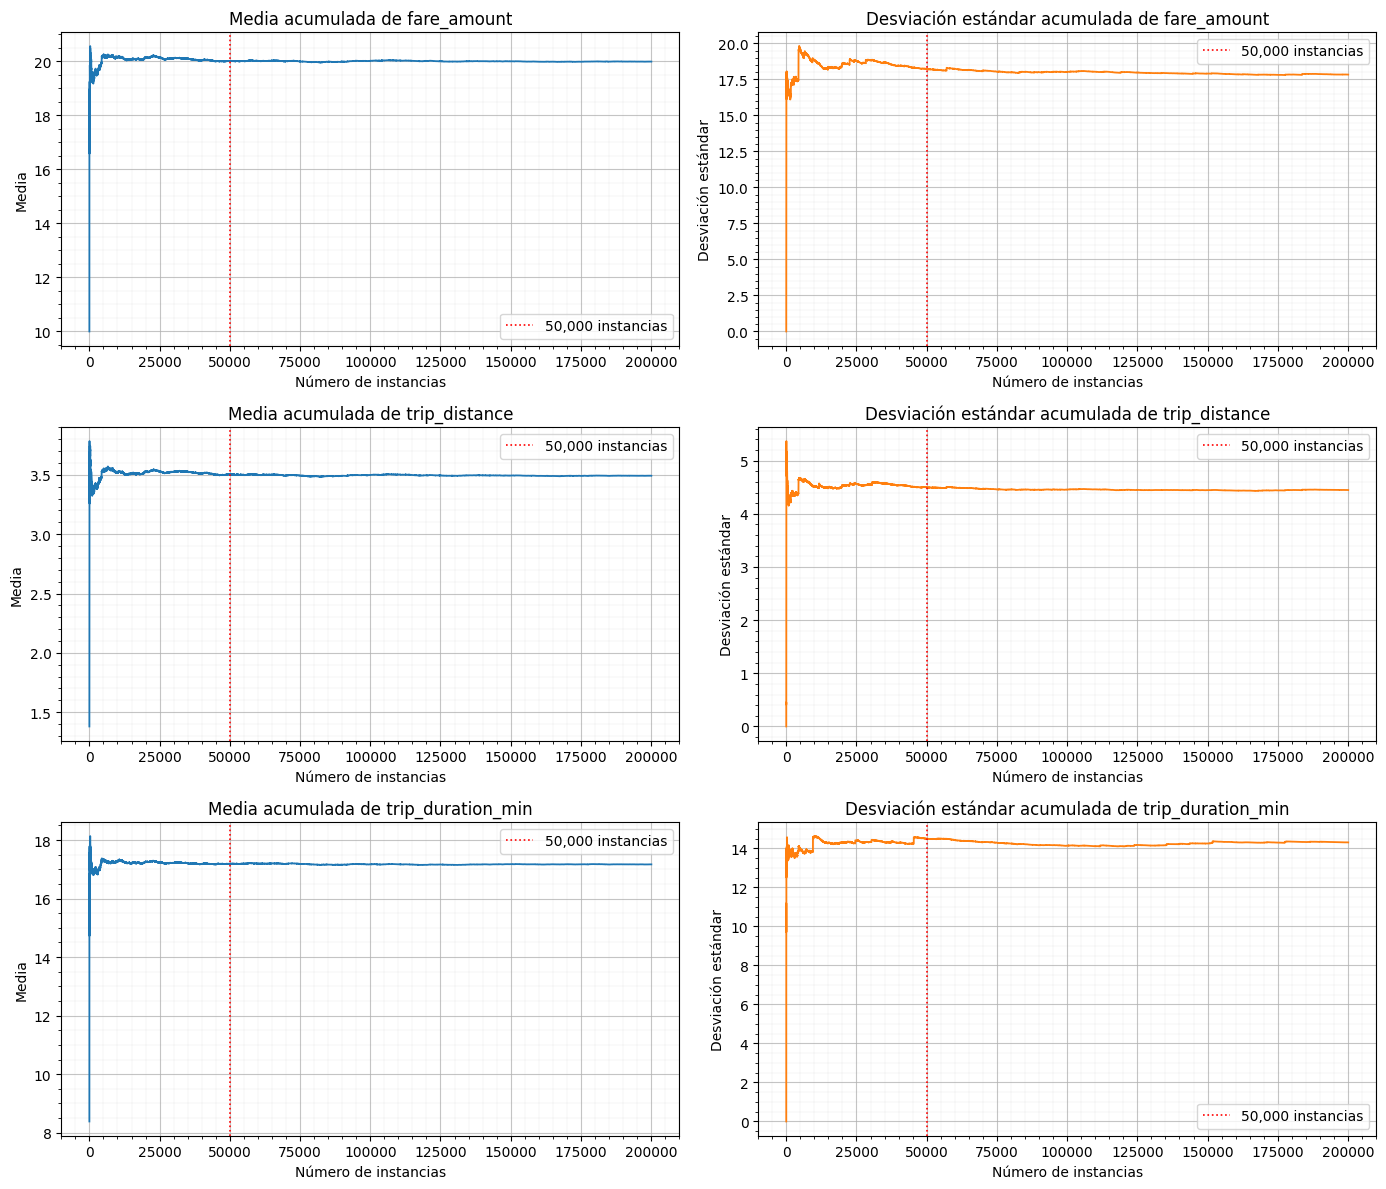

In [21]:
MEAN_GRAPH_INDEX = 0
ST_DEV_GRAPH_INDEX = 1

x_ticks = np.arange(0, len(conv_pdf) + 1, 25_000)
stability_label = f"{POINT_ESTABILIZACION:,} instancias"

fig, ax = plt.subplots(len(cols), 2, figsize=(14, 12))
for j, col in enumerate(cols):
    running_mean = running_stats[col]["mean"]
    running_std = running_stats[col]["std"]

    ax[j, MEAN_GRAPH_INDEX].plot(n, running_mean, linewidth=1.3)
    ax[j, MEAN_GRAPH_INDEX].axvline(
        POINT_ESTABILIZACION,
        color="red",
        linestyle=":",
        linewidth=1.2,
        label=stability_label,
    )
    ax[j, MEAN_GRAPH_INDEX].set_title(f"Media acumulada de {col}")
    ax[j, MEAN_GRAPH_INDEX].set_xlabel("Número de instancias")
    ax[j, MEAN_GRAPH_INDEX].set_ylabel("Media")
    ax[j, MEAN_GRAPH_INDEX].set_xticks(x_ticks)
    ax[j, MEAN_GRAPH_INDEX].ticklabel_format(style="plain", axis="x")
    ax[j, MEAN_GRAPH_INDEX].grid(True, which="major", linewidth=0.8, alpha=0.75)
    ax[j, MEAN_GRAPH_INDEX].minorticks_on()
    ax[j, MEAN_GRAPH_INDEX].grid(True, which="minor", linewidth=0.35, alpha=0.25)
    ax[j, MEAN_GRAPH_INDEX].legend(loc="best")

    ax[j, ST_DEV_GRAPH_INDEX].plot(n, running_std, color="tab:orange", linewidth=1.3)
    ax[j, ST_DEV_GRAPH_INDEX].axvline(
        POINT_ESTABILIZACION,
        color="red",
        linestyle=":",
        linewidth=1.2,
        label=stability_label,
    )
    ax[j, ST_DEV_GRAPH_INDEX].set_title(f"Desviación estándar acumulada de {col}")
    ax[j, ST_DEV_GRAPH_INDEX].set_xlabel("Número de instancias")
    ax[j, ST_DEV_GRAPH_INDEX].set_ylabel("Desviación estándar")
    ax[j, ST_DEV_GRAPH_INDEX].set_xticks(x_ticks)
    ax[j, ST_DEV_GRAPH_INDEX].ticklabel_format(style="plain", axis="x")
    ax[j, ST_DEV_GRAPH_INDEX].grid(True, which="major", linewidth=0.8, alpha=0.75)
    ax[j, ST_DEV_GRAPH_INDEX].minorticks_on()
    ax[j, ST_DEV_GRAPH_INDEX].grid(True, which="minor", linewidth=0.35, alpha=0.25)
    ax[j, ST_DEV_GRAPH_INDEX].legend(loc="best")

plt.tight_layout()
plt.show()


**Interpretación del gráfico.** Las curvas de estabilidad muestran que al aumentar el tamaño muestral las medias y desviaciones estándar se acercan a su valor final. A partir de 50,000 registros se estabilizan las variables evaluadas bajo los umbrales definidos, por lo que la muestra M de más de 5 millones de viajes queda ampliamente por encima del mínimo empírico necesario.


In [22]:
stability_df = stability_checkpoint_df[
    stability_checkpoint_df["n_referencia"] == POINT_ESTABILIZACION
].reset_index(drop=True)

selected_pos = stability_checkpoint_summary_df.index[
    stability_checkpoint_summary_df["n_referencia"] == POINT_ESTABILIZACION
][0]
stability_threshold_evidence_df = stability_checkpoint_summary_df.iloc[
    max(0, selected_pos - 1) : min(
        len(stability_checkpoint_summary_df), selected_pos + 2
    )
].copy()

display(stability_threshold_evidence_df.round(4))
display(stability_df.round(4))

M_duration_for_conv.unpersist()


,n_referencia,variables_estables,max_cambio_abs_media,max_cambio_rel_desv_std_pct,todas_variables_estables,estable_desde_aqui
8,45000,2,0.0133,2.6895,False,False
9,50000,3,0.0196,2.1756,True,True
10,55000,3,0.0230,1.7541,True,True


,n_referencia,variable,media_en_n,media_final_200k,cambio_abs_media,tolerancia_media_abs,cumple_media,desv_std_en_n,desv_std_final_200k,cambio_rel_desv_std_pct,tolerancia_desv_std_rel_pct,cumple_desv_std,cumple_variable
0,50000,fare_amount,20.0079,19.9883,0.0196,0.10,True,18.2252,17.8372,2.1756,2.5,True,True
1,50000,trip_distance,3.5030,3.4922,0.0108,0.05,True,4.4995,4.4475,1.1686,2.5,True,True
2,50000,trip_duration_min,17.1887,17.1691,0.0196,0.10,True,14.5030,14.3115,1.3380,2.5,True,True


DataFrame[fare_amount: float, trip_distance: float, tpep_pickup_datetime: timestamp_ntz, tpep_dropoff_datetime: timestamp_ntz, trip_duration_min: float]

**Lectura de la sección.** La muestra estratificada M queda en 5,029,725 viajes y cubre los 240 estratos definidos. Esto mantiene la metodología de Etapa 3, donde se concluyó que un muestreo estratificado era más adecuado que una muestra aleatoria simple porque protege combinaciones relevantes de zona, pago, horario y distancia. Las diferencias marginales frente a D son pequeñas: Manhattan baja 0.533 puntos porcentuales, airport sube 0.108, credit baja 0.386 y las categorías de distancia se mantienen dentro de desviaciones menores. El análisis de estabilidad muestra que desde 50,000 registros las medias y desviaciones estándar cumplen el criterio de estabilidad, mientras que `MIN_PER_STRATUM=500` opera como piso de cobertura para estratos pequeños. Son criterios complementarios: uno protege diversidad por estrato y el otro valida estabilidad global.


<a id="seccion-5"></a>
# 5. Preparación de conjuntos de entrenamiento y prueba

Esta sección reproduce el split 80/20 estratificado definido en Etapa 3. En esa entrega se estableció que la separación train/test debía hacerse dentro de cada `stratum_id` para no perder cobertura de patrones poblacionales en ninguno de los subconjuntos. Por eso, la partición no solo busca una proporción 80/20, sino conservar zonas, métodos de pago, horarios y rangos de distancia en train y test.


La siguiente celda construye train y test mediante ventana estratificada.


In [23]:
TRAIN_RATIO = 0.80
SPLIT_SEED = 123

counts_M = M.groupBy("stratum_id").count().withColumnRenamed("count", "n_M_s")
w_split = Window.partitionBy("stratum_id").orderBy(F.rand(seed=SPLIT_SEED))

M_split = (
    M.join(counts_M, "stratum_id")
    .withColumn("rn", F.row_number().over(w_split))
    .withColumn(
        "split_id", F.concat_ws("|", F.col("stratum_id"), F.col("rn").cast("string"))
    )
    .withColumn(
        "train_cutoff", F.floor(F.lit(TRAIN_RATIO) * F.col("n_M_s")).cast("long")
    )
    .cache()
)

train_df = (
    M_split.filter(F.col("rn") <= F.col("train_cutoff"))
    .drop("rn", "train_cutoff", "n_M_s")
    .cache()
)

test_df = (
    M_split.filter(F.col("rn") > F.col("train_cutoff"))
    .drop("rn", "train_cutoff", "n_M_s")
    .cache()
)

n_train = train_df.count()
n_test = test_df.count()

print(f"Filas train: {n_train:,}")
print(f"Filas test: {n_test:,}")
print(f"Proporción train: {n_train / (n_train + n_test):.4f}")

assert n_train + n_test == n_M, "Train + test debe reconstruir M"


Filas train: 4,023,683
Filas test: 1,006,042
Proporción train: 0.8000


La siguiente celda valida que train y test sean disjuntos, reconstruyan M y conserven los 240 estratos.


In [24]:
intersection_count = (
    train_df.select("split_id").intersect(test_df.select("split_id")).count()
)
union_distinct_count = (
    train_df.unionByName(test_df).select("split_id").distinct().count()
)

print(f"Intersección train-test por split_id: {intersection_count:,}")
print(f"Distinct split_id en unión train-test: {union_distinct_count:,}")

assert intersection_count == 0, "Train y test no deben solaparse"
assert union_distinct_count == n_M, "La unión train-test debe reconstruir M"

strata_train = train_df.select("stratum_id").distinct().count()
strata_test = test_df.select("stratum_id").distinct().count()
min_train = train_df.groupBy("stratum_id").count().agg(F.min("count")).first()[0]
min_test = test_df.groupBy("stratum_id").count().agg(F.min("count")).first()[0]

print(f"Estratos en train: {strata_train}")
print(f"Estratos en test: {strata_test}")
print(f"Mínimo por estrato en train: {min_train}")
print(f"Mínimo por estrato en test: {min_test}")

assert (
    strata_train == 240 and strata_test == 240
), "Train y test deben conservar 240 estratos"


Intersección train-test por split_id: 0
Distinct split_id en unión train-test: 5,029,725
Estratos en train: 240
Estratos en test: 240
Mínimo por estrato en train: 42
Mínimo por estrato en test: 11


La siguiente celda compara marginales entre train y test en las cuatro variables de caracterización.


In [25]:
split_balance_rows = []
for column_name in characterization_cols:
    p_train = collect_distribution(train_df, column_name, n_train)
    p_test = collect_distribution(test_df, column_name, n_test)
    for category in sorted(set(p_train) | set(p_test)):
        tr = p_train.get(category, 0.0)
        ts = p_test.get(category, 0.0)
        split_balance_rows.append(
            {
                "variable": column_name,
                "categoria": str(category),
                "pct_train": round(tr * 100, 4),
                "pct_test": round(ts * 100, 4),
                "diff_pp_train_menos_test": round((tr - ts) * 100, 4),
            }
        )

split_balance_pdf = pd.DataFrame(split_balance_rows)
display(split_balance_pdf)


,variable,categoria,pct_train,pct_test,diff_pp_train_menos_test
0,pu_macro_zone,airport,7.5336,7.5359,-0.0022
1,pu_macro_zone,manhattan,86.9672,86.9597,0.0075
2,pu_macro_zone,outer_borough,4.9501,4.9527,-0.0026
3,pu_macro_zone,unknown,0.5491,0.5518,-0.0027
4,payment_group,cash,11.5377,11.5399,-0.0021
5,payment_group,credit,71.8384,71.8328,0.0056
6,payment_group,flex,14.9175,14.9185,-0.0010
7,payment_group,other,1.7064,1.7089,-0.0025
8,day_hour_bucket,late_night,8.5650,8.5664,-0.0015
9,day_hour_bucket,other,31.1567,31.1554,0.0013


La siguiente celda deriva duración del viaje y filtra duraciones fuera de [0.5, 720] minutos para los conjuntos modelables.


In [26]:
def add_trip_duration(df):
    return (
        df.withColumn(
            "trip_duration_min_raw",
            (
                F.unix_timestamp("tpep_dropoff_datetime")
                - F.unix_timestamp("tpep_pickup_datetime")
            )
            / F.lit(60.0),
        )
        .filter(F.col("trip_duration_min_raw").between(0.5, 720.0))
        .withColumn("trip_duration_min", F.col("trip_duration_min_raw").cast("float"))
        .drop("trip_duration_min_raw")
    )


train_base_ml = (
    add_trip_duration(train_df)
    .withColumn("is_flex_fare", F.col("is_flex_fare").cast("byte"))
    .cache()
)
test_base_ml = (
    add_trip_duration(test_df)
    .withColumn("is_flex_fare", F.col("is_flex_fare").cast("byte"))
    .cache()
)

n_train_base_ml = train_base_ml.count()
n_test_base_ml = test_base_ml.count()

print(f"Train antes de filtro de duración: {n_train:,}")
print(f"Test antes de filtro de duración: {n_test:,}")
print(f"Train para modelado: {n_train_base_ml:,}")
print(f"Test para modelado: {n_test_base_ml:,}")
print(f"Pérdida train por duración: {(n_train - n_train_base_ml) / n_train * 100:.3f}%")
print(f"Pérdida test por duración: {(n_test - n_test_base_ml) / n_test * 100:.3f}%")


Train antes de filtro de duración: 4,023,683
Test antes de filtro de duración: 1,006,042
Train para modelado: 3,986,017
Test para modelado: 996,458
Pérdida train por duración: 0.936%
Pérdida test por duración: 0.953%


**Lectura de la sección.** El holdout conserva el tamaño esperado, con 4,023,683 registros en train y 1,006,042 en test, una razón 80/20 sin intersección entre subconjuntos. Ambos subconjuntos mantienen los 240 estratos y las diferencias marginales son mínimas, con máximos alrededor de centésimas de punto porcentual. Al filtrar duración para modelado quedan 3,986,017 registros de train y 996,458 de test, con pérdidas cercanas a 0.94% y 0.95%, respectivamente. Esto preserva el diseño de muestreo y evita que el modelado use viajes temporalmente inconsistentes.


<a id="seccion-6"></a>
# 6. Selección de métricas para medir calidad

Las métricas se fijan antes del entrenamiento. En regresión se reportan RMSE, MAE y R2. En clustering se reportan silhouette, balance de clusters e interpretabilidad de perfiles. Matriz de confusión y ROC no aplican porque no hay una tarea de clasificación; se sustituyen por residuales, real contra predicho, RMSE por segmento, curva de complejidad, silhouette y perfiles de arquetipos.


**Lectura de la sección.** Las métricas se usan con roles distintos: RMSE penaliza errores grandes en la predicción de tarifa, MAE resume el error típico más interpretable en dólares y R2 mide la proporción de variabilidad explicada. En validación cruzada, la media y la desviación estándar de estas métricas permiten revisar estabilidad entre particiones. Para no supervisado, silhouette evalúa separación relativa entre arquetipos y las proporciones por cluster controlan que la solución no colapse en un solo grupo dominante.


<a id="seccion-7"></a>
# 7. Experimentación: entrenamiento y selección de modelos

Esta sección usa el holdout 80/20 definido en Etapa 3 para seleccionar modelos. En esa etapa se compararon alternativas supervisadas y no supervisadas con una partición estable, y se concluyó que la selección debía hacerse sobre ese holdout para no cambiar el criterio de evaluación a mitad del proyecto. La validación cruzada de la sección 8 no reabre esta selección: mide estabilidad de los ganadores y verifica que los resultados no dependan de una única partición.


## 7.1 Track supervisado: regresión de `fare_amount`

Se define el pipeline supervisado con 8 features operativas y exclusión explícita de variables monetarias posteriores al cobro para evitar fuga de información.


In [27]:
TARGET = "fare_amount"
SUPERVISED_CAT_COLS = [
    "pu_macro_zone",
    "RatecodeID",
    "day_hour_bucket",
    "cbd_period_flag",
]
SUPERVISED_NUM_COLS = [
    "trip_distance",
    "trip_duration_min",
    "is_flex_fare",
    "passenger_count",
]
SUPERVISED_FEATURE_COLS = [
    "trip_distance",
    "trip_duration_min",
    "pu_macro_zone",
    "RatecodeID",
    "is_flex_fare",
    "day_hour_bucket",
    "cbd_period_flag",
    "passenger_count",
]
LEAKAGE_COLS = {
    "total_amount",
    "tip_amount",
    "tolls_amount",
    "extra",
    "mta_tax",
    "improvement_surcharge",
    "congestion_surcharge",
    "Airport_fee",
    "cbd_congestion_fee",
}

assert set(SUPERVISED_FEATURE_COLS) == set(SUPERVISED_CAT_COLS + SUPERVISED_NUM_COLS)
assert TARGET not in SUPERVISED_FEATURE_COLS
assert not (
    set(SUPERVISED_FEATURE_COLS) & LEAKAGE_COLS
), "Hay columnas con fuga en las features"

missing_supervised = sorted(
    set(SUPERVISED_FEATURE_COLS + [TARGET]) - set(train_base_ml.columns)
)
assert (
    not missing_supervised
), f"Columnas faltantes para supervisado: {missing_supervised}"

supervised_indexers = [
    StringIndexer(inputCol=col_name, outputCol=f"{col_name}_idx", handleInvalid="keep")
    for col_name in SUPERVISED_CAT_COLS
]
supervised_encoder = OneHotEncoder(
    inputCols=[f"{col_name}_idx" for col_name in SUPERVISED_CAT_COLS],
    outputCols=[f"{col_name}_ohe" for col_name in SUPERVISED_CAT_COLS],
)
supervised_assembler = VectorAssembler(
    inputCols=SUPERVISED_NUM_COLS
    + [f"{col_name}_ohe" for col_name in SUPERVISED_CAT_COLS],
    outputCol="features",
    handleInvalid="keep",
)

supervised_preprocessing = supervised_indexers + [
    supervised_encoder,
    supervised_assembler,
]

ev_rmse = RegressionEvaluator(
    labelCol=TARGET, predictionCol="prediction", metricName="rmse"
)
ev_mae = RegressionEvaluator(
    labelCol=TARGET, predictionCol="prediction", metricName="mae"
)
ev_r2 = RegressionEvaluator(
    labelCol=TARGET, predictionCol="prediction", metricName="r2"
)

print("Features supervisadas:", SUPERVISED_FEATURE_COLS)
print("Columnas monetarias excluidas por fuga:", sorted(LEAKAGE_COLS))


Features supervisadas: ['trip_distance', 'trip_duration_min', 'pu_macro_zone', 'RatecodeID', 'is_flex_fare', 'day_hour_bucket', 'cbd_period_flag', 'passenger_count']
Columnas monetarias excluidas por fuga: ['Airport_fee', 'cbd_congestion_fee', 'congestion_surcharge', 'extra', 'improvement_surcharge', 'mta_tax', 'tip_amount', 'tolls_amount', 'total_amount']


La siguiente celda entrena `LinearRegression` como baseline rápido e interpretable.


In [28]:
lr = LinearRegression(
    featuresCol="features",
    labelCol=TARGET,
    regParam=0.0,
    elasticNetParam=0.0,
    maxIter=100,
)

pipeline_lr = Pipeline(stages=supervised_preprocessing + [lr])

t0 = time.time()
model_lr = pipeline_lr.fit(train_base_ml)
lr_fit_seconds = time.time() - t0

pred_lr = model_lr.transform(test_base_ml).cache()

metrics_lr = {
    "modelo": "LinearRegression",
    "rmse": ev_rmse.evaluate(pred_lr),
    "mae": ev_mae.evaluate(pred_lr),
    "r2": ev_r2.evaluate(pred_lr),
    "fit_seconds": lr_fit_seconds,
}

print(metrics_lr)


{'modelo': 'LinearRegression', 'rmse': 5.595138572242773, 'mae': 2.453751991817976, 'r2': 0.900296892097442, 'fit_seconds': 4.75140905380249}


La siguiente celda entrena `RandomForestRegressor` con `TrainValidationSplit` dentro del conjunto de entrenamiento.


In [29]:
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol=TARGET,
    featureSubsetStrategy="auto",
    seed=SEED_M,
)

pipeline_rf = Pipeline(stages=supervised_preprocessing + [rf])

param_grid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [30, 50])
    .addGrid(rf.maxDepth, [6, 8, 10])
    .addGrid(rf.subsamplingRate, [1.0])
    .build()
)

tvs = TrainValidationSplit(
    estimator=pipeline_rf,
    estimatorParamMaps=param_grid,
    evaluator=ev_rmse,
    trainRatio=0.75,
    parallelism=2,
    seed=SEED_M,
)

t0 = time.time()
tvs_model = tvs.fit(train_base_ml)
rf_fit_seconds = time.time() - t0

validation_rows = []
for params, rmse_value in zip(param_grid, tvs_model.validationMetrics):
    validation_rows.append(
        {param.name: value for param, value in params.items()}
        | {"rmse_validacion": float(rmse_value)}
    )

validation_results_pdf = pd.DataFrame(validation_rows).sort_values("rmse_validacion")
display(validation_results_pdf)

best_pipeline_rf = tvs_model.bestModel
pred_rf = best_pipeline_rf.transform(test_base_ml).cache()

metrics_rf = {
    "modelo": "RandomForestRegressor",
    "rmse": ev_rmse.evaluate(pred_rf),
    "mae": ev_mae.evaluate(pred_rf),
    "r2": ev_r2.evaluate(pred_rf),
    "fit_seconds": rf_fit_seconds,
}

print(metrics_rf)


,numTrees,maxDepth,subsamplingRate,rmse_validacion
5,50,10,1.0,5.096630
2,30,10,1.0,5.109744
4,50,8,1.0,5.246516
1,30,8,1.0,5.263093
3,50,6,1.0,5.682404
0,30,6,1.0,5.714892


{'modelo': 'RandomForestRegressor', 'rmse': 4.966316459845805, 'mae': 1.5594343730164217, 'r2': 0.9214482649834418, 'fit_seconds': 218.19197916984558}


La siguiente celda compara el baseline lineal contra Random Forest y calcula error por segmento tarifario.


In [30]:
supervised_results_pdf = pd.DataFrame([metrics_lr, metrics_rf])
display(supervised_results_pdf)

segment_rows = []
for segment_name, segment_value in [("Metered", 0), ("Flex Fare", 1)]:
    segment_pred = pred_rf.filter(F.col("is_flex_fare") == segment_value).cache()
    segment_n = segment_pred.count()
    segment_rows.append(
        {
            "segmento": segment_name,
            "n": segment_n,
            "rmse": ev_rmse.evaluate(segment_pred),
            "mae": ev_mae.evaluate(segment_pred),
        }
    )
    segment_pred.unpersist()

rf_segment_results_pdf = pd.DataFrame(segment_rows)
display(rf_segment_results_pdf)

_ = pred_lr.unpersist()
_ = pred_rf.unpersist()


,modelo,rmse,mae,r2,fit_seconds
0,LinearRegression,5.595139,2.453752,0.900297,4.751409
1,RandomForestRegressor,4.966316,1.559434,0.921448,218.191979


,segmento,n,rmse,mae
0,Metered,846601,4.284716,1.035874
1,Flex Fare,149857,7.764443,4.517235


**Lectura de la sección.** El baseline de regresión lineal logra RMSE 5.595, MAE 2.454 y R2 0.900, mientras que Random Forest mejora a RMSE 4.966, MAE 1.559 y R2 0.921. La configuración ganadora usa 50 árboles y profundidad máxima 10, con mejor RMSE de validación dentro de la grilla. El costo de entrenamiento es mayor que el baseline, pero el resultado justifica el uso del modelo no lineal. Por segmento, Metered presenta RMSE 4.285 y MAE 1.036, mientras Flex Fare sube a RMSE 7.764 y MAE 4.517, lo que indica que el modelo representa mejor los viajes medidos por taxímetro que los esquemas flexibles.


## 7.2 Track no supervisado: clustering de arquetipos

El clustering busca arquetipos operativos sin usar una etiqueta objetivo. Se excluyen importes monetarios para que los grupos describan forma y contexto del viaje, no niveles de cobro.


In [31]:
AVERAGE_SPEED_CAP_MPH = 40.0

train_cluster_ml = (
    train_base_ml.withColumn(
        "average_speed_mph",
        F.col("trip_distance") / (F.col("trip_duration_min") / F.lit(60.0)),
    )
    .withColumn(
        "average_speed_mph_capped",
        F.least(F.col("average_speed_mph"), F.lit(AVERAGE_SPEED_CAP_MPH)),
    )
    .cache()
)

test_cluster_ml = (
    test_base_ml.withColumn(
        "average_speed_mph",
        F.col("trip_distance") / (F.col("trip_duration_min") / F.lit(60.0)),
    )
    .withColumn(
        "average_speed_mph_capped",
        F.least(F.col("average_speed_mph"), F.lit(AVERAGE_SPEED_CAP_MPH)),
    )
    .cache()
)

CLUSTER_NUM_COLS = [
    "trip_distance",
    "trip_duration_min",
    "passenger_count",
    "average_speed_mph_capped",
]
CLUSTER_CAT_COLS = ["pu_macro_zone", "RatecodeID", "day_hour_bucket"]
CLUSTER_BIN_COLS = ["is_flex_fare"]
CLUSTER_FEATURE_COLS = CLUSTER_NUM_COLS + CLUSTER_CAT_COLS + CLUSTER_BIN_COLS
PROFILE_ONLY_COLS = ["cbd_period_flag", "average_speed_mph"]

EXCLUDED_CLUSTER_AMOUNT_COLS = {
    "fare_amount",
    "total_amount",
    "tip_amount",
    "tolls_amount",
    "extra",
    "mta_tax",
    "improvement_surcharge",
    "congestion_surcharge",
    "Airport_fee",
    "cbd_congestion_fee",
}

assert len(CLUSTER_FEATURE_COLS) == 8
assert "cbd_period_flag" not in CLUSTER_FEATURE_COLS
assert not (set(CLUSTER_FEATURE_COLS) & EXCLUDED_CLUSTER_AMOUNT_COLS)

cluster_indexers = [
    StringIndexer(inputCol=col_name, outputCol=f"{col_name}_idx", handleInvalid="keep")
    for col_name in CLUSTER_CAT_COLS
]
cluster_encoder = OneHotEncoder(
    inputCols=[f"{col_name}_idx" for col_name in CLUSTER_CAT_COLS],
    outputCols=[f"{col_name}_ohe" for col_name in CLUSTER_CAT_COLS],
)
num_assembler = VectorAssembler(
    inputCols=CLUSTER_NUM_COLS, outputCol="num_features", handleInvalid="keep"
)
scaler = StandardScaler(
    inputCol="num_features",
    outputCol="scaled_num_features",
    withMean=True,
    withStd=True,
)
cluster_assembler = VectorAssembler(
    inputCols=["scaled_num_features"]
    + [f"{col_name}_ohe" for col_name in CLUSTER_CAT_COLS]
    + CLUSTER_BIN_COLS,
    outputCol="features",
    handleInvalid="keep",
)

cluster_preprocess_pipeline = Pipeline(
    stages=cluster_indexers
    + [cluster_encoder, num_assembler, scaler, cluster_assembler]
)
cluster_preprocess_model = cluster_preprocess_pipeline.fit(train_cluster_ml)

train_features = cluster_preprocess_model.transform(train_cluster_ml).cache()
test_features = cluster_preprocess_model.transform(test_cluster_ml).cache()

n_train_features = train_features.count()
n_test_features = test_features.count()

print(f"Features clustering ({len(CLUSTER_FEATURE_COLS)}): {CLUSTER_FEATURE_COLS}")
print(f"Filas con features train: {n_train_features:,}")
print(f"Filas con features test: {n_test_features:,}")


Features clustering (8): ['trip_distance', 'trip_duration_min', 'passenger_count', 'average_speed_mph_capped', 'pu_macro_zone', 'RatecodeID', 'day_hour_bucket', 'is_flex_fare']
Filas con features train: 3,986,017
Filas con features test: 996,458


La siguiente celda diagnostica el cap de velocidad promedio en 40 mph.


In [32]:
speed_quantile_probs = [0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
speed_quantiles = train_cluster_ml.approxQuantile(
    "average_speed_mph", speed_quantile_probs, 0.001
)

speed_cap_rows = []
for prob, value in zip(speed_quantile_probs, speed_quantiles):
    speed_cap_rows.append({"percentil": prob, "average_speed_mph": value})

n_above_speed_cap = train_cluster_ml.filter(
    F.col("average_speed_mph") > AVERAGE_SPEED_CAP_MPH
).count()
pct_above_speed_cap = n_above_speed_cap / n_train_features * 100

print(f"Cap de velocidad media: {AVERAGE_SPEED_CAP_MPH:.1f} mph")
print(
    f"Viajes train por encima del cap: {n_above_speed_cap:,} ({pct_above_speed_cap:.4f}%)"
)
display(pd.DataFrame(speed_cap_rows))


Cap de velocidad media: 40.0 mph
Viajes train por encima del cap: 14,279 (0.3582%)


,percentil,average_speed_mph
0,0.500,9.381356
1,0.750,12.964854
2,0.900,19.099820
3,0.950,24.253821
4,0.990,34.513465
5,0.999,4482.857154


La siguiente celda barre KMeans para `k` en [3, 4, 5, 6].


In [33]:
K_VALUES = [3, 4, 5, 6]
KMEANS_MAX_ITER = 30

kmeans_evaluator = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="cluster",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean",
)

kmeans_models = {}
kmeans_rows = []

for k in K_VALUES:
    kmeans = KMeans(
        featuresCol="features",
        predictionCol="cluster",
        k=k,
        seed=SEED_M,
        maxIter=KMEANS_MAX_ITER,
    )
    model = kmeans.fit(train_features)
    kmeans_models[k] = model

    pred_train_k = model.transform(train_features).select("features", "cluster")
    pred_test_k = model.transform(test_features).select("features", "cluster")

    cluster_sizes = pred_train_k.groupBy("cluster").count().cache()
    size_stats = cluster_sizes.agg(
        F.min("count").alias("min_cluster"),
        F.max("count").alias("max_cluster"),
    ).first()
    cluster_sizes.unpersist()

    kmeans_rows.append(
        {
            "modelo": f"KMeans_k_{k}",
            "k": k,
            "training_cost": float(model.summary.trainingCost),
            "silhouette_train": float(kmeans_evaluator.evaluate(pred_train_k)),
            "silhouette_test": float(kmeans_evaluator.evaluate(pred_test_k)),
            "min_cluster": int(size_stats["min_cluster"]),
            "max_cluster": int(size_stats["max_cluster"]),
            "max_cluster_fraction": float(size_stats["max_cluster"] / n_train_features),
        }
    )

kmeans_results_pdf = pd.DataFrame(kmeans_rows).sort_values("k")
display(kmeans_results_pdf)


,modelo,k,training_cost,silhouette_train,silhouette_test,min_cluster,max_cluster,max_cluster_fraction
0,KMeans_k_3,3,1.282950e+07,0.491448,0.491598,536166,2854210,0.716056
1,KMeans_k_4,4,1.193320e+07,0.375543,0.377448,103425,2853164,0.715793
2,KMeans_k_5,5,1.013852e+07,0.455639,0.455857,199897,2586403,0.648869
3,KMeans_k_6,6,9.747580e+06,0.240329,0.240804,222072,1346659,0.337846


La siguiente celda fija KMeans con `k=5`, configuración canónica de Etapa 3. Esa elección se conserva porque en la comparación previa ofreció el mejor balance entre separación, tamaño de clusters e interpretabilidad de perfiles operativos; cambiarla aquí afectaría la comparabilidad del resultado final.


In [34]:
# La justificación de k=5 se desarrolla en la lectura del track no supervisado.
SELECTED_K = 5

kmeans_final = kmeans_models.get(SELECTED_K)
if kmeans_final is None:
    kmeans_final = KMeans(
        featuresCol="features",
        predictionCol="cluster",
        k=SELECTED_K,
        seed=SEED_M,
        maxIter=KMEANS_MAX_ITER,
    ).fit(train_features)

kmeans_train = kmeans_final.transform(train_features).cache()
kmeans_test = kmeans_final.transform(test_features).cache()

final_kmeans_sil_train = kmeans_evaluator.evaluate(
    kmeans_train.select("features", "cluster")
)
final_kmeans_sil_test = kmeans_evaluator.evaluate(
    kmeans_test.select("features", "cluster")
)

kmeans_counts = (
    kmeans_train.groupBy("cluster")
    .count()
    .withColumn(
        "cluster_fraction", F.round(F.col("count") / F.lit(n_train_features), 4)
    )
    .orderBy("cluster")
)

print(f"KMeans final k={SELECTED_K}")
print(f"Silhouette train: {final_kmeans_sil_train:.4f}")
print(f"Silhouette test: {final_kmeans_sil_test:.4f}")
kmeans_counts.show(truncate=False)


KMeans final k=5
Silhouette train: 0.4556
Silhouette test: 0.4559
+-------+-------+----------------+
|cluster|count  |cluster_fraction|
+-------+-------+----------------+
|0      |542923 |0.1362          |
|1      |199897 |0.0501          |
|2      |2586403|0.6489          |
|3      |423588 |0.1063          |
|4      |233206 |0.0585          |
+-------+-------+----------------+



La siguiente celda perfila los clusters para asignar nombres operativos compatibles con Etapa 3. Esos nombres no son etiquetas oficiales del TLC, sino una síntesis interpretativa construida a partir de distancia, duración, velocidad, pasajeros, zona de origen, tipo de tarifa y método de pago.


In [35]:
def top_category_by_cluster(df, col_name, cluster_col="cluster"):
    w_top = Window.partitionBy(cluster_col).orderBy(F.desc("count"), F.asc(col_name))
    return (
        df.groupBy(cluster_col, col_name)
        .count()
        .withColumn("rn_top", F.row_number().over(w_top))
        .filter(F.col("rn_top") == 1)
        .select(
            F.col(cluster_col),
            F.col(col_name).alias(f"top_{col_name}"),
            F.col("count").alias(f"top_{col_name}_n"),
        )
    )


kmeans_numeric_profile = kmeans_train.groupBy("cluster").agg(
    F.count("*").alias("n"),
    F.round(F.avg("trip_distance"), 2).alias("avg_distance_mi"),
    F.round(F.expr("percentile_approx(trip_distance, 0.5, 1000)"), 2).alias(
        "median_distance_mi"
    ),
    F.round(F.avg("trip_duration_min"), 2).alias("avg_duration_min"),
    F.round(F.expr("percentile_approx(trip_duration_min, 0.5, 1000)"), 2).alias(
        "median_duration_min"
    ),
    F.round(F.avg("average_speed_mph_capped"), 2).alias("avg_speed_capped_mph"),
    F.round(F.avg("passenger_count"), 2).alias("avg_passengers"),
    F.round(F.avg("is_flex_fare"), 4).alias("fraction_flex"),
)

kmeans_profile = kmeans_numeric_profile
for profile_col in [
    "pu_macro_zone",
    "RatecodeID",
    "day_hour_bucket",
    "cbd_period_flag",
]:
    kmeans_profile = kmeans_profile.join(
        top_category_by_cluster(kmeans_train, profile_col), "cluster", "left"
    )

kmeans_profile.orderBy("cluster").show(truncate=False)

_ = kmeans_train.unpersist()
_ = kmeans_test.unpersist()


+-------+-------+---------------+------------------+----------------+-------------------+--------------------+--------------+-------------+-----------------+-------------------+--------------+----------------+-------------------+---------------------+-------------------+---------------------+
|cluster|n      |avg_distance_mi|median_distance_mi|avg_duration_min|median_duration_min|avg_speed_capped_mph|avg_passengers|fraction_flex|top_pu_macro_zone|top_pu_macro_zone_n|top_RatecodeID|top_RatecodeID_n|top_day_hour_bucket|top_day_hour_bucket_n|top_cbd_period_flag|top_cbd_period_flag_n|
+-------+-------+---------------+------------------+----------------+-------------------+--------------------+--------------+-------------+-----------------+-------------------+--------------+----------------+-------------------+---------------------+-------------------+---------------------+
|0      |542923 |2.76           |2.36              |17.43           |15.37              |9.85                |1.0     

La siguiente celda entrena GaussianMixture como comparación probabilística.


In [36]:
GMM_MAX_ITER = 20

gmm = GaussianMixture(
    featuresCol="features",
    predictionCol="gmm_cluster",
    probabilityCol="gmm_probability",
    k=SELECTED_K,
    seed=SEED_M,
    maxIter=GMM_MAX_ITER,
)

gmm_model = gmm.fit(train_features)
gmm_train = gmm_model.transform(train_features).cache()
gmm_test = gmm_model.transform(test_features).cache()

gmm_evaluator = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="gmm_cluster",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean",
)

gmm_train_profile = gmm_train.withColumn(
    "gmm_prob_max", F.array_max(vector_to_array("gmm_probability"))
)

gmm_counts = (
    gmm_train_profile.groupBy("gmm_cluster")
    .agg(
        F.count("*").alias("count"),
        F.round(F.count("*") / F.lit(n_train_features), 4).alias("cluster_fraction"),
        F.round(F.avg("gmm_prob_max"), 4).alias("avg_max_probability"),
    )
    .orderBy("gmm_cluster")
)

gmm_metrics = {
    "modelo": "GaussianMixture",
    "k": SELECTED_K,
    "silhouette_train": gmm_evaluator.evaluate(
        gmm_train.select("features", "gmm_cluster")
    ),
    "silhouette_test": gmm_evaluator.evaluate(
        gmm_test.select("features", "gmm_cluster")
    ),
    "log_likelihood_train": float(gmm_model.summary.logLikelihood),
}

print(gmm_metrics)
gmm_counts.show(truncate=False)

_ = gmm_train.unpersist()
_ = gmm_test.unpersist()


[462.045s][warning][gc,alloc] Executor task launch worker for task 54.0 in stage 1406.0 (TID 105139): Retried waiting for GCLocker too often allocating 146431 words
[462.045s][warning][gc,alloc] Executor task launch worker for task 195.0 in stage 1406.0 (TID 105280): Retried waiting for GCLocker too often allocating 69124 words
[462.045s][warning][gc,alloc] Executor task launch worker for task 192.0 in stage 1406.0 (TID 105277): Retried waiting for GCLocker too often allocating 33838 words


{'modelo': 'GaussianMixture', 'k': 5, 'silhouette_train': 0.35387036590582543, 'silhouette_test': 0.35446290864690616, 'log_likelihood_train': 135766556.9261461}
+-----------+-------+----------------+-------------------+
|gmm_cluster|count  |cluster_fraction|avg_max_probability|
+-----------+-------+----------------+-------------------+
|0          |192009 |0.0482          |0.9895             |
|1          |2920951|0.7328          |0.9999             |
|2          |624458 |0.1567          |0.9997             |
|3          |61043  |0.0153          |0.9959             |
|4          |187556 |0.0471          |1.0                |
+-----------+-------+----------------+-------------------+



La siguiente celda resume la comparación KMeans contra GMM.


In [37]:
clustering_model_results_pdf = pd.DataFrame(
    [
        {
            "modelo": "KMeans",
            "k": SELECTED_K,
            "silhouette_train": final_kmeans_sil_train,
            "silhouette_test": final_kmeans_sil_test,
            "log_likelihood_train": "No aplica",
        },
        gmm_metrics,
    ]
)

display(clustering_model_results_pdf)

for cached_df in [
    train_features,
    test_features,
    train_cluster_ml,
    test_cluster_ml,
    train_base_ml,
    test_base_ml,
    train_df,
    test_df,
    M_split,
    M,
]:
    try:
        cached_df.unpersist()
    except Exception:
        pass


,modelo,k,silhouette_train,silhouette_test,log_likelihood_train
0,KMeans,5,0.455639,0.455857,No aplica
1,GaussianMixture,5,0.353870,0.354463,135766556.926146


**Lectura de la sección.** La selección de `k=5` se sostiene porque obtiene el mejor balance entre silhouette de test y distribución de tamaños: alcanza 0.456 y evita concentrar casi todos los viajes en un solo cluster. GMM queda por debajo, con silhouette de test 0.354 y un componente dominante de 73.28%, por lo que es menos útil para describir arquetipos operativos. Los perfiles resultantes son interpretables y se alinean con patrones esperados del taxi: urbano regular corto, Flex urbano, viajes medianos rápidos, aeropuerto/largo y pasajeros múltiples urbanos.


<a id="seccion-8"></a>
# 8. Validación cruzada: estabilidad de los modelos ganadores

Esta sección reutiliza el punto de estabilización calculado en la sección 4.1 y construye 5 folds estratificados sobre M. Los modelos ganadores ya están fijados: RF con `maxDepth=10` y KMeans con `k=5`, `seed=244`.


La siguiente celda compara candidatos de K contra el punto de estabilización y fija `K_FOLDS=5`.


In [38]:
K_FOLDS = 5
K_CANDIDATES = [3, 4, 5, 6, 10]

k_candidate_df = pd.DataFrame(
    [
        {
            "k_folds": k,
            "n_test_aprox": int(n_M // k),
            "multiplo_vs_estabilizacion": (n_M / k) / POINT_ESTABILIZACION,
        }
        for k in K_CANDIDATES
    ]
)

display(k_candidate_df.round(2))

assert K_FOLDS == 5
assert n_M / K_FOLDS > POINT_ESTABILIZACION


,k_folds,n_test_aprox,multiplo_vs_estabilizacion
0,3,1676575,33.53
1,4,1257431,25.15
2,5,1005945,20.12
3,6,838287,16.77
4,10,502972,10.06


La siguiente celda asigna folds estratificados dentro de cada `stratum_id`.


In [39]:
SEED_FOLDS = 123

w_fold = Window.partitionBy("stratum_id").orderBy(F.rand(seed=SEED_FOLDS))

M_folds = (
    M.withColumn("rn_fold", F.row_number().over(w_fold))
    .withColumn("fold_id", F.ntile(K_FOLDS).over(w_fold))
    .withColumn(
        "fold_row_id",
        F.concat_ws("|", F.col("stratum_id"), F.col("rn_fold").cast("string")),
    )
    .persist(StorageLevel.MEMORY_AND_DISK)
)

n_M_folds = M_folds.count()
print(f"Filas en M_folds: {n_M_folds:,}")
assert n_M_folds == n_M, "M_folds debe conservar todas las filas de M"


Filas en M_folds: 5,029,725


Las siguientes celdas validan tamaño de folds, cobertura de estratos y balance marginal.


In [40]:
fold_sizes = (
    M_folds.groupBy("fold_id")
    .count()
    .withColumnRenamed("count", "n_fold")
    .orderBy("fold_id")
    .withColumn("pct_M", F.round(F.col("n_fold") / F.lit(n_M) * 100, 4))
)
fold_sizes_df = fold_sizes.cache()
fold_sizes_pdf = fold_sizes_df.toPandas()
display(fold_sizes_pdf)

fold_partition_check = M_folds.agg(
    F.count("*").alias("n_rows"),
    F.countDistinct("fold_row_id").alias("n_distinct_fold_row_id"),
    F.countDistinct("fold_id").alias("n_folds"),
).toPandas()
display(fold_partition_check)

assert int(fold_partition_check.loc[0, "n_rows"]) == n_M
assert int(fold_partition_check.loc[0, "n_distinct_fold_row_id"]) == n_M
assert int(fold_partition_check.loc[0, "n_folds"]) == K_FOLDS


,fold_id,n_fold,pct_M
0,1,1006042,20.0019
1,2,1005991,20.0009
2,3,1005943,20.0000
3,4,1005895,19.9990
4,5,1005854,19.9982


,n_rows,n_distinct_fold_row_id,n_folds
0,5029725,5029725,5


In [41]:
strata_per_fold = (
    M_folds.groupBy("fold_id")
    .agg(F.countDistinct("stratum_id").alias("n_strata"))
    .orderBy("fold_id")
)
display(strata_per_fold.toPandas())

assert (
    strata_per_fold.filter(F.col("n_strata") != n_strata_M).count() == 0
), "Cada fold debe contener los 240 estratos"


,fold_id,n_strata
0,1,240
1,2,240
2,3,240
3,4,240
4,5,240


In [42]:
dist_balance_tables = []
for col_name in characterization_cols:
    base_dist = (
        M.groupBy(col_name)
        .count()
        .withColumnRenamed("count", "n_M_col")
        .withColumn("p_M_col", F.col("n_M_col") / F.lit(n_M))
    )
    fold_dist = (
        M_folds.groupBy("fold_id", col_name)
        .count()
        .join(fold_sizes_df, "fold_id")
        .withColumn("p_fold_col", F.col("count") / F.col("n_fold"))
    )
    diff = fold_dist.join(base_dist, col_name, "left").withColumn(
        "abs_diff_pp", F.abs(F.col("p_fold_col") - F.col("p_M_col")) * 100
    )
    dist_balance_tables.append(
        diff.groupBy("fold_id")
        .agg(F.round(F.max("abs_diff_pp"), 4).alias("max_abs_diff_pp"))
        .withColumn("variable", F.lit(col_name))
        .select("variable", "fold_id", "max_abs_diff_pp")
    )

dist_balance_df = reduce(lambda a, b: a.unionByName(b), dist_balance_tables)
display(dist_balance_df.orderBy("variable", "fold_id").toPandas())


,variable,fold_id,max_abs_diff_pp
0,day_hour_bucket,1,0.0012
1,day_hour_bucket,2,0.0008
2,day_hour_bucket,3,0.0002
3,day_hour_bucket,4,0.0008
4,day_hour_bucket,5,0.0010
5,payment_group,1,0.0045
6,payment_group,2,0.0021
7,payment_group,3,0.0004
8,payment_group,4,0.0020
9,payment_group,5,0.0043


La siguiente celda deriva duración para los folds y prepara la base modelable.


In [43]:
M_folds_ml = (
    add_trip_duration(M_folds)
    .withColumn("is_flex_fare", F.col("is_flex_fare").cast("byte"))
    .persist(StorageLevel.MEMORY_AND_DISK)
)
n_M_model = M_folds_ml.count()

print(f"Filas en M antes de filtro de duración: {n_M:,}")
print(f"Filas modelables tras filtro de duración: {n_M_model:,}")
print(f"Pérdida por filtro de duración: {(n_M - n_M_model) / n_M * 100:.3f}%")

M.unpersist()
M_folds.unpersist()


Filas en M antes de filtro de duración: 5,029,725
Filas modelables tras filtro de duración: 4,982,475
Pérdida por filtro de duración: 0.939%


DataFrame[VendorID: tinyint, tpep_pickup_datetime: timestamp_ntz, tpep_dropoff_datetime: timestamp_ntz, passenger_count: tinyint, trip_distance: float, RatecodeID: tinyint, store_and_fwd_flag: string, PULocationID: smallint, DOLocationID: smallint, payment_type: tinyint, fare_amount: float, extra: float, mta_tax: float, tip_amount: float, tolls_amount: float, improvement_surcharge: float, total_amount: float, congestion_surcharge: float, Airport_fee: float, cbd_congestion_fee: float, pu_macro_zone: string, payment_group: string, pickup_hour: int, dow: int, day_hour_bucket: string, trip_distance_bin: string, is_flex_fare: boolean, cbd_period_flag: string, stratum_id: string, rn_fold: int, fold_id: int, fold_row_id: string]

La siguiente celda define el pipeline supervisado ganador para validación cruzada.


In [44]:
TARGET = "fare_amount"
MODEL_SEED = 42
SUPERVISED_CAT_COLS = [
    "pu_macro_zone",
    "RatecodeID",
    "day_hour_bucket",
    "cbd_period_flag",
]
SUPERVISED_NUM_COLS = [
    "trip_distance",
    "trip_duration_min",
    "is_flex_fare",
    "passenger_count",
]
SUPERVISED_FEATURE_COLS = SUPERVISED_NUM_COLS + SUPERVISED_CAT_COLS
LEAKAGE_COLS = {
    "total_amount",
    "tip_amount",
    "tolls_amount",
    "extra",
    "mta_tax",
    "improvement_surcharge",
    "congestion_surcharge",
    "Airport_fee",
    "cbd_congestion_fee",
}

assert TARGET not in SUPERVISED_FEATURE_COLS
assert not (
    set(SUPERVISED_FEATURE_COLS) & LEAKAGE_COLS
), "Hay columnas con fuga en las features"
missing_supervised = sorted(
    set(SUPERVISED_FEATURE_COLS + [TARGET]) - set(M_folds_ml.columns)
)
assert (
    not missing_supervised
), f"Columnas faltantes para supervisado: {missing_supervised}"

supervised_indexers = [
    StringIndexer(inputCol=col_name, outputCol=f"{col_name}_idx", handleInvalid="keep")
    for col_name in SUPERVISED_CAT_COLS
]
supervised_encoder = OneHotEncoder(
    inputCols=[f"{col_name}_idx" for col_name in SUPERVISED_CAT_COLS],
    outputCols=[f"{col_name}_ohe" for col_name in SUPERVISED_CAT_COLS],
)
supervised_assembler = VectorAssembler(
    inputCols=SUPERVISED_NUM_COLS
    + [f"{col_name}_ohe" for col_name in SUPERVISED_CAT_COLS],
    outputCol="features",
    handleInvalid="keep",
)

supervised_preprocessing = supervised_indexers + [
    supervised_encoder,
    supervised_assembler,
]

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol=TARGET,
    numTrees=50,
    maxDepth=10,
    subsamplingRate=1.0,
    featureSubsetStrategy="auto",
    seed=MODEL_SEED,
)

pipeline = Pipeline(stages=supervised_preprocessing + [rf])

ev_rmse = RegressionEvaluator(
    labelCol=TARGET, predictionCol="prediction", metricName="rmse"
)
ev_mae = RegressionEvaluator(
    labelCol=TARGET, predictionCol="prediction", metricName="mae"
)
ev_r2 = RegressionEvaluator(
    labelCol=TARGET, predictionCol="prediction", metricName="r2"
)

print("Features supervisadas:", SUPERVISED_FEATURE_COLS)


Features supervisadas: ['trip_distance', 'trip_duration_min', 'is_flex_fare', 'passenger_count', 'pu_macro_zone', 'RatecodeID', 'day_hour_bucket', 'cbd_period_flag']


La siguiente celda define el pipeline KMeans ganador para validación cruzada.


In [45]:
KMEANS_CLUSTERS = 5
KMEANS_MAX_ITER = 30
KMEANS_SEED = 244
AVERAGE_SPEED_CAP_MPH = 40.0

CLUSTER_NUM_COLS = [
    "trip_distance",
    "trip_duration_min",
    "passenger_count",
    "average_speed_mph_capped",
]
CLUSTER_CAT_COLS = ["pu_macro_zone", "RatecodeID", "day_hour_bucket"]
CLUSTER_BIN_COLS = ["is_flex_fare"]
CLUSTER_PROFILE_COLS = (
    CLUSTER_NUM_COLS + CLUSTER_BIN_COLS + ["is_post_cbd_period", TARGET]
)


def add_cluster_features(df):
    return (
        df.withColumn(
            "average_speed_mph",
            F.col("trip_distance") / (F.col("trip_duration_min") / F.lit(60.0)),
        )
        .withColumn(
            "average_speed_mph_capped",
            F.least(F.col("average_speed_mph"), F.lit(AVERAGE_SPEED_CAP_MPH)),
        )
        .withColumn(
            "is_post_cbd_period",
            F.when(F.col("cbd_period_flag") == "post_cbd", F.lit(1.0)).otherwise(
                F.lit(0.0)
            ),
        )
    )


missing_cluster_base = sorted(
    set(
        ["trip_distance", "trip_duration_min", "passenger_count", "is_flex_fare"]
        + CLUSTER_CAT_COLS
    )
    - set(M_folds_ml.columns)
)
assert (
    not missing_cluster_base
), f"Columnas faltantes para clustering: {missing_cluster_base}"

cluster_indexers = [
    StringIndexer(inputCol=col_name, outputCol=f"{col_name}_idx", handleInvalid="keep")
    for col_name in CLUSTER_CAT_COLS
]
cluster_encoder = OneHotEncoder(
    inputCols=[f"{col_name}_idx" for col_name in CLUSTER_CAT_COLS],
    outputCols=[f"{col_name}_ohe" for col_name in CLUSTER_CAT_COLS],
)
cluster_num_assembler = VectorAssembler(
    inputCols=CLUSTER_NUM_COLS,
    outputCol="cluster_num_features",
    handleInvalid="keep",
)
cluster_scaler = StandardScaler(
    inputCol="cluster_num_features",
    outputCol="cluster_num_scaled",
    withMean=True,
    withStd=True,
)
cluster_assembler = VectorAssembler(
    inputCols=["cluster_num_scaled"]
    + [f"{col_name}_ohe" for col_name in CLUSTER_CAT_COLS]
    + CLUSTER_BIN_COLS,
    outputCol="features",
    handleInvalid="keep",
)
cluster_preprocessing = cluster_indexers + [
    cluster_encoder,
    cluster_num_assembler,
    cluster_scaler,
    cluster_assembler,
]

kmeans = KMeans(
    featuresCol="features",
    predictionCol="cluster",
    k=KMEANS_CLUSTERS,
    seed=KMEANS_SEED,
    maxIter=KMEANS_MAX_ITER,
)
cluster_pipeline = Pipeline(stages=cluster_preprocessing + [kmeans])
cluster_evaluator = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="cluster",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean",
)

print("Features no supervisadas numéricas:", CLUSTER_NUM_COLS)
print("Features no supervisadas categóricas:", CLUSTER_CAT_COLS)


Features no supervisadas numéricas: ['trip_distance', 'trip_duration_min', 'passenger_count', 'average_speed_mph_capped']
Features no supervisadas categóricas: ['pu_macro_zone', 'RatecodeID', 'day_hour_bucket']


La siguiente celda ejecuta validación cruzada supervisada y recolecta métricas por fold.


In [46]:
fold_sizes_model = {
    row["fold_id"]: row["count"]
    for row in M_folds_ml.groupBy("fold_id").count().collect()
}
n_M_model = sum(fold_sizes_model.values())

resultados = []
seg_rows = []
scatter_pdf = None

for i in range(1, K_FOLDS + 1):
    test_fold = M_folds_ml.filter(F.col("fold_id") == i)
    train_fold = M_folds_ml.filter(F.col("fold_id") != i)

    t0 = time.time()
    model_i = pipeline.fit(train_fold)
    fit_seconds = time.time() - t0

    pred_test = (
        model_i.transform(test_fold)
        .select(TARGET, "prediction", "is_flex_fare")
        .persist(StorageLevel.MEMORY_AND_DISK)
    )
    pred_test.count()

    pred_train = (
        model_i.transform(train_fold.sample(fraction=0.25, seed=42 + i))
        .select(TARGET, "prediction")
        .persist(StorageLevel.MEMORY_AND_DISK)
    )
    pred_train.count()

    resultados.append(
        {
            "fold": i,
            "rmse_test": ev_rmse.evaluate(pred_test),
            "mae_test": ev_mae.evaluate(pred_test),
            "r2_test": ev_r2.evaluate(pred_test),
            "rmse_train": ev_rmse.evaluate(pred_train),
            "mae_train": ev_mae.evaluate(pred_train),
            "r2_train": ev_r2.evaluate(pred_train),
            "fit_seconds": fit_seconds,
            "n_train": n_M_model - fold_sizes_model[i],
            "n_test": fold_sizes_model[i],
        }
    )

    for flex_val in (0, 1):
        seg = pred_test.filter(F.col("is_flex_fare") == flex_val)
        seg_n = seg.count()
        seg_rows.append(
            {
                "fold": i,
                "segmento": "Flex Fare" if flex_val else "Metered",
                "n": seg_n,
                "rmse": ev_rmse.evaluate(seg) if seg_n else np.nan,
            }
        )

    if i == 1:
        scatter_pdf = pred_test.sample(
            fraction=min(1.0, 5000 / fold_sizes_model[i]), seed=42
        ).toPandas()

    pred_train.unpersist()
    pred_test.unpersist()

cv_df = pd.DataFrame(resultados)
seg_df = pd.DataFrame(seg_rows)

display(cv_df.round(4))
display(
    cv_df[
        [
            "rmse_test",
            "mae_test",
            "r2_test",
            "rmse_train",
            "mae_train",
            "r2_train",
            "fit_seconds",
        ]
    ]
    .agg(["mean", "std"])
    .round(4)
)


,fold,rmse_test,mae_test,r2_test,rmse_train,mae_train,r2_train,fit_seconds,n_train,n_test
0,1,5.2738,1.5639,0.9133,5.1520,1.5653,0.9173,63.8927,3985781,996694
1,2,5.1205,1.5831,0.9177,5.1811,1.5829,0.9162,64.0974,3985965,996510
2,3,4.9678,1.5822,0.9221,5.1328,1.5718,0.9174,64.2947,3985934,996541
3,4,5.2913,1.5741,0.9130,5.1915,1.5700,0.9163,64.4625,3986036,996439
4,5,5.0164,1.5702,0.9203,5.1065,1.5698,0.9176,65.1389,3986184,996291


,rmse_test,mae_test,r2_test,rmse_train,mae_train,r2_train,fit_seconds
mean,5.1340,1.5747,0.9173,5.1528,1.5719,0.9170,64.3772
std,0.1466,0.0081,0.0041,0.0348,0.0066,0.0007,0.4762


La siguiente celda ejecuta validación por folds no supervisada y recolecta silhouette, balance y perfiles.


In [47]:
cluster_rows = []
cluster_balance_rows = []
cluster_profile_pdf = None
cluster_profile_rows = []
TRAIN_SILHOUETTE_SAMPLE_N = 500_000

for i in range(1, K_FOLDS + 1):
    test_fold = add_cluster_features(M_folds_ml.filter(F.col("fold_id") == i))
    train_fold = add_cluster_features(M_folds_ml.filter(F.col("fold_id") != i))

    t0 = time.time()
    cluster_model_i = cluster_pipeline.fit(train_fold)
    fit_seconds = time.time() - t0

    pred_train_cluster = (
        cluster_model_i.transform(train_fold)
        .select("features", "cluster")
        .persist(StorageLevel.MEMORY_AND_DISK)
    )
    n_train_cluster = pred_train_cluster.count()
    pred_train_cluster_sample = pred_train_cluster.sample(
        fraction=min(1.0, TRAIN_SILHOUETTE_SAMPLE_N / n_train_cluster), seed=240 + i
    ).persist(StorageLevel.MEMORY_AND_DISK)
    pred_train_cluster_sample.count()

    pred_test_cluster = (
        cluster_model_i.transform(test_fold)
        .select("features", "cluster", *CLUSTER_PROFILE_COLS)
        .persist(StorageLevel.MEMORY_AND_DISK)
    )
    n_test_cluster = pred_test_cluster.count()

    train_silhouette = cluster_evaluator.evaluate(pred_train_cluster_sample)
    test_silhouette = cluster_evaluator.evaluate(
        pred_test_cluster.select("features", "cluster")
    )

    test_counts_pdf = pred_test_cluster.groupBy("cluster").count().toPandas()
    test_counts_pdf["fold"] = i
    test_counts_pdf["fraction"] = test_counts_pdf["count"] / n_test_cluster
    test_counts_pdf = test_counts_pdf.rename(columns={"count": "n_test"})
    cluster_balance_rows.extend(test_counts_pdf.to_dict("records"))

    cluster_rows.append(
        {
            "fold": i,
            "silhouette_train_sample": train_silhouette,
            "silhouette_test": test_silhouette,
            "fit_seconds": fit_seconds,
            "n_train_sample": pred_train_cluster_sample.count(),
            "n_test": n_test_cluster,
            "min_cluster_fraction_test": test_counts_pdf["fraction"].min(),
            "max_cluster_fraction_test": test_counts_pdf["fraction"].max(),
        }
    )

    profile_exprs = [
        F.avg(F.col(col_name).cast("double")).alias(col_name)
        for col_name in CLUSTER_PROFILE_COLS
    ]
    profile_fold_pdf = (
        pred_test_cluster.groupBy("cluster")
        .agg(F.count("*").alias("n"), *profile_exprs)
        .orderBy("cluster")
        .toPandas()
    )
    profile_fold_pdf.insert(0, "fold", i)
    cluster_profile_rows.extend(profile_fold_pdf.to_dict("records"))

    if i == 1:
        cluster_profile_pdf = profile_fold_pdf.drop(columns=["fold"]).copy()

    pred_train_cluster_sample.unpersist()
    pred_train_cluster.unpersist()
    pred_test_cluster.unpersist()

cluster_cv_df = pd.DataFrame(cluster_rows)
cluster_balance_df = pd.DataFrame(cluster_balance_rows)
cluster_profile_all_df = pd.DataFrame(cluster_profile_rows)

display(cluster_cv_df.round(4))

cluster_balance_preview_df = cluster_balance_df.sort_values(["fold", "cluster"]).head(
    10
)
display(cluster_balance_preview_df.round(4))

display(cluster_profile_pdf.round(4))

cluster_profile_preview_df = cluster_profile_all_df.sort_values(
    ["fold", "cluster"]
).head(5)
display(cluster_profile_preview_df.round(4))

print(
    f"Validación cruzada KMeans completa: {len(cluster_cv_df)} folds y {len(cluster_profile_all_df)} perfiles fold-cluster para la sección 9.2."
)


,fold,silhouette_train_sample,silhouette_test,fit_seconds,n_train_sample,n_test,min_cluster_fraction_test,max_cluster_fraction_test
0,1,0.4173,0.4172,12.7866,499473,996694,0.0562,0.5644
1,2,0.4578,0.4587,12.0188,499518,996510,0.0507,0.6563
2,3,0.4161,0.4168,11.8000,498564,996541,0.0566,0.5635
3,4,0.4581,0.4584,11.9555,501454,996439,0.0499,0.6572
4,5,0.4575,0.4588,11.7403,499755,996291,0.0503,0.6566


,cluster,n_test,fold,fraction
4,0,562568,1,0.5644
0,1,138699,1,0.1392
3,2,55985,1,0.0562
1,3,147144,1,0.1476
2,4,92298,1,0.0926
9,0,50541,2,0.0507
5,1,97112,2,0.0975
8,2,654057,2,0.6563
6,3,57281,2,0.0575
7,4,137519,2,0.1380


,cluster,n,trip_distance,trip_duration_min,passenger_count,average_speed_mph_capped,is_flex_fare,is_post_cbd_period,fare_amount
0,0,562568,1.7709,12.7625,1.0000,8.8343,0.0000,0.4935,13.4034
1,1,138699,2.8474,17.5183,1.0000,10.0393,0.9478,0.6904,19.2636
2,2,55985,17.1398,57.8370,1.4312,19.4590,0.0531,0.5075,70.2277
3,3,147144,2.0207,13.8122,2.5893,9.0369,0.0000,0.4674,14.8374
4,4,92298,9.0917,24.5731,1.1571,23.2975,0.1670,0.5352,39.1260


,fold,cluster,n,trip_distance,trip_duration_min,passenger_count,average_speed_mph_capped,is_flex_fare,is_post_cbd_period,fare_amount
0,1,0,562568,1.7709,12.7625,1.0000,8.8343,0.0000,0.4935,13.4034
1,1,1,138699,2.8474,17.5183,1.0000,10.0393,0.9478,0.6904,19.2636
2,1,2,55985,17.1398,57.8370,1.4312,19.4590,0.0531,0.5075,70.2277
3,1,3,147144,2.0207,13.8122,2.5893,9.0369,0.0000,0.4674,14.8374
4,1,4,92298,9.0917,24.5731,1.1571,23.2975,0.1670,0.5352,39.1260


Validación cruzada KMeans completa: 5 folds y 25 perfiles fold-cluster para la sección 9.2.


La siguiente celda calcula la curva de complejidad supervisada sobre una submuestra diagnóstica.


In [48]:
COMPLEXITY_FOLD = 1
COMPLEXITY_DEPTHS = [4, 8, 12]
train_complex_base = M_folds_ml.filter(F.col("fold_id") != COMPLEXITY_FOLD)
test_complex_base = M_folds_ml.filter(F.col("fold_id") == COMPLEXITY_FOLD)

train_complex_fraction = min(
    1.0, 250_000 / (n_M_model - fold_sizes_model[COMPLEXITY_FOLD])
)
test_complex_fraction = min(1.0, 100_000 / fold_sizes_model[COMPLEXITY_FOLD])

train_complex = train_complex_base.sample(
    fraction=train_complex_fraction, seed=420
).persist(StorageLevel.MEMORY_AND_DISK)
test_complex = test_complex_base.sample(
    fraction=test_complex_fraction, seed=421
).persist(StorageLevel.MEMORY_AND_DISK)
train_complex.count()
test_complex.count()

complexity_rows = []
for depth in COMPLEXITY_DEPTHS:
    rf_depth = RandomForestRegressor(
        featuresCol="features",
        labelCol=TARGET,
        numTrees=50,
        maxDepth=depth,
        subsamplingRate=1.0,
        featureSubsetStrategy="auto",
        seed=MODEL_SEED,
    )
    pipeline_depth = Pipeline(stages=supervised_preprocessing + [rf_depth])
    t0 = time.time()
    model_depth = pipeline_depth.fit(train_complex)
    fit_seconds = time.time() - t0

    pred_train_depth = (
        model_depth.transform(train_complex)
        .select(TARGET, "prediction")
        .persist(StorageLevel.MEMORY_AND_DISK)
    )
    pred_test_depth = (
        model_depth.transform(test_complex)
        .select(TARGET, "prediction")
        .persist(StorageLevel.MEMORY_AND_DISK)
    )
    pred_train_depth.count()
    pred_test_depth.count()

    complexity_rows.append(
        {
            "maxDepth": depth,
            "rmse_train": ev_rmse.evaluate(pred_train_depth),
            "rmse_test": ev_rmse.evaluate(pred_test_depth),
            "fit_seconds": fit_seconds,
        }
    )

    pred_train_depth.unpersist()
    pred_test_depth.unpersist()

train_complex.unpersist()
test_complex.unpersist()

complexity_df = pd.DataFrame(complexity_rows)
display(complexity_df.round(4))


,maxDepth,rmse_train,rmse_test,fit_seconds
0,4,6.9263,6.7810,5.9439
1,8,5.2251,5.2582,13.6918
2,12,4.7113,5.0929,34.8236


**Lectura de la sección.** La validación cruzada supervisada es estable: RMSE promedio 5.134 con desviación estándar 0.147, MAE promedio 1.575 con desviación 0.008 y R2 promedio 0.917 con desviación 0.004. En no supervisado, el silhouette promedio es 0.442 con desviación 0.023, suficiente para sostener que la estructura existe aunque con variabilidad moderada por fold. La curva de complejidad muestra mejora clara de profundidad 4 a 8, pero en profundidad 12 el RMSE de train sigue bajando mientras el de test mejora poco, señal de beneficio marginal y mayor riesgo de sobreajuste.


<a id="seccion-9"></a>
# 9. Presentación de resultados

Las visualizaciones se separan por track para que las métricas de regresión y clustering no se mezclen. Cada gráfico queda acompañado por una interpretación inmediata y cada subsección cierra con una lectura integrada de resultados.


## 9.1 Resultados del track supervisado

La primera gráfica revisa el balance de `fare_amount` entre folds.


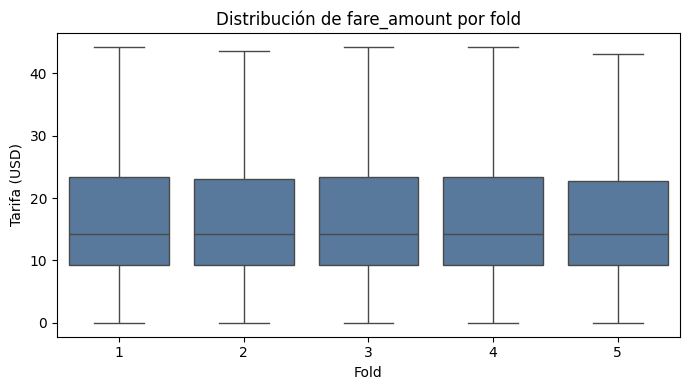

,fold_id,mediana,q1,q3,iqr
0,1,14.2,9.3,23.299999,14.000
1,2,14.2,9.3,23.080000,13.780
2,3,14.2,9.3,23.299999,14.000
3,4,14.2,9.3,23.299999,14.000
4,5,14.2,9.3,22.815001,13.515


In [49]:
fare_box_fraction = min(1.0, 20_000 / (n_M_model / K_FOLDS))
fare_box_pdf = (
    M_folds_ml.select("fold_id", TARGET)
    .sampleBy("fold_id", {i: fare_box_fraction for i in range(1, K_FOLDS + 1)}, seed=42)
    .toPandas()
)

plt.figure(figsize=(7, 4))
sns.boxplot(data=fare_box_pdf, x="fold_id", y=TARGET, showfliers=False, color="#4C78A8")
plt.title("Distribución de fare_amount por fold")
plt.xlabel("Fold")
plt.ylabel("Tarifa (USD)")
plt.tight_layout()
plt.show()

fare_fold_summary = (
    fare_box_pdf.groupby("fold_id")[TARGET]
    .agg(mediana="median", q1=lambda s: s.quantile(0.25), q3=lambda s: s.quantile(0.75))
    .reset_index()
)
fare_fold_summary["iqr"] = fare_fold_summary["q3"] - fare_fold_summary["q1"]
display(fare_fold_summary.round(4))


**Interpretación del gráfico.** Los boxplots por fold mantienen medianas e intervalos intercuartílicos muy parecidos, con mediana cercana a 14.2 USD. Esto indica que la partición en folds no altera de forma material la distribución de la tarifa y que la validación cruzada compara subconjuntos equivalentes.


La siguiente gráfica muestra RMSE, MAE y R2 en prueba por fold.


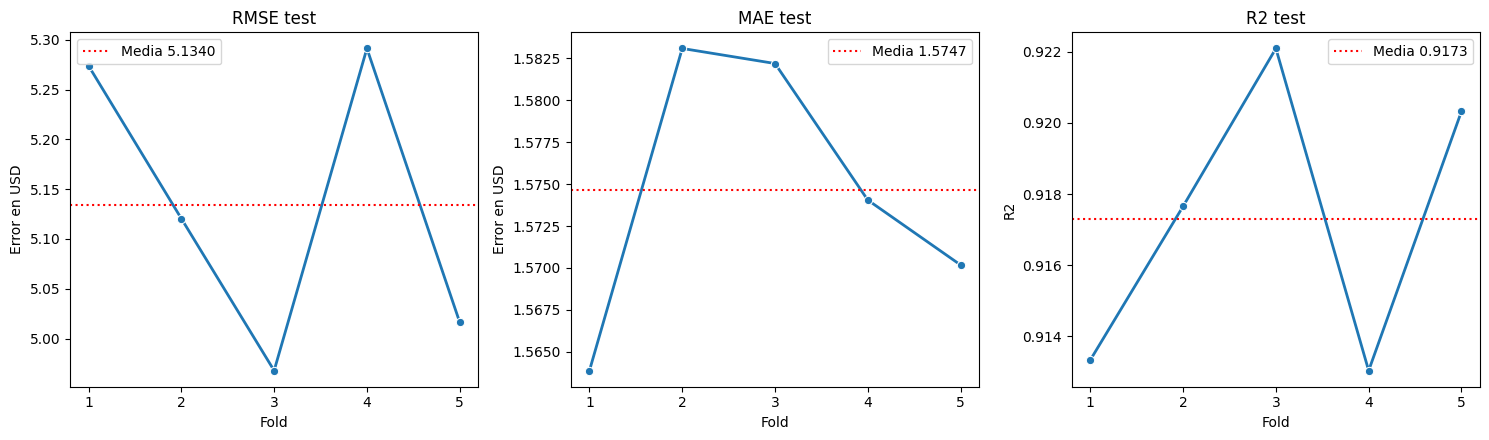

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metric_specs = [
    ("rmse_test", "RMSE test", "Error en USD"),
    ("mae_test", "MAE test", "Error en USD"),
    ("r2_test", "R2 test", "R2"),
]
for ax, (metric, title, ylabel) in zip(axes, metric_specs):
    sns.lineplot(data=cv_df, x="fold", y=metric, marker="o", linewidth=2, ax=ax)
    mean_val = cv_df[metric].mean()
    ax.axhline(
        mean_val,
        color="red",
        linestyle=":",
        linewidth=1.5,
        label=f"Media {mean_val:.4f}",
    )
    ax.set_title(title)
    ax.set_xlabel("Fold")
    ax.set_ylabel(ylabel)
    ax.set_xticks(sorted(cv_df["fold"].unique()))
    ax.legend(loc="best")
plt.tight_layout()
plt.show()


**Interpretación del gráfico.** Las líneas de RMSE, MAE y R2 se mantienen en rangos estrechos entre folds. La variación existe, pero no cambia la conclusión del modelo: Random Forest conserva desempeño estable y no depende de un fold excepcional para sostener sus métricas.


La siguiente gráfica muestra la brecha `RMSE_test - RMSE_train` por fold.


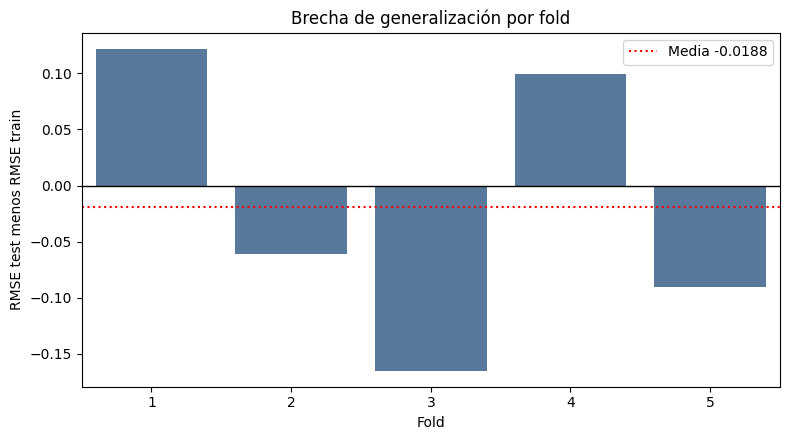

,fold,rmse_train,rmse_test,rmse_gap
0,1,5.1520,5.2738,0.1218
1,2,5.1811,5.1205,-0.0606
2,3,5.1328,4.9678,-0.1650
3,4,5.1915,5.2913,0.0998
4,5,5.1065,5.0164,-0.0901


In [51]:
gap_df = cv_df.assign(rmse_gap=cv_df["rmse_test"] - cv_df["rmse_train"])
plt.figure(figsize=(8, 4.5))
sns.barplot(data=gap_df, x="fold", y="rmse_gap", color="#4C78A8")
plt.axhline(
    gap_df["rmse_gap"].mean(),
    color="red",
    linestyle=":",
    linewidth=1.5,
    label=f"Media {gap_df['rmse_gap'].mean():.4f}",
)
plt.axhline(0, color="black", linewidth=1)
plt.title("Brecha de generalización por fold")
plt.xlabel("Fold")
plt.ylabel("RMSE test menos RMSE train")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

display(gap_df[["fold", "rmse_train", "rmse_test", "rmse_gap"]].round(4))


**Interpretación del gráfico.** La brecha entre RMSE de test y train oscila cerca de cero, con valores pequeños en todos los folds. Esta lectura reduce la preocupación por sobreajuste fuerte en la configuración validada, aunque sigue siendo necesario revisar complejidad porque modelos más profundos pueden memorizar más sin mejorar proporcionalmente el test.


La siguiente gráfica muestra la curva de complejidad para distintas profundidades del bosque.


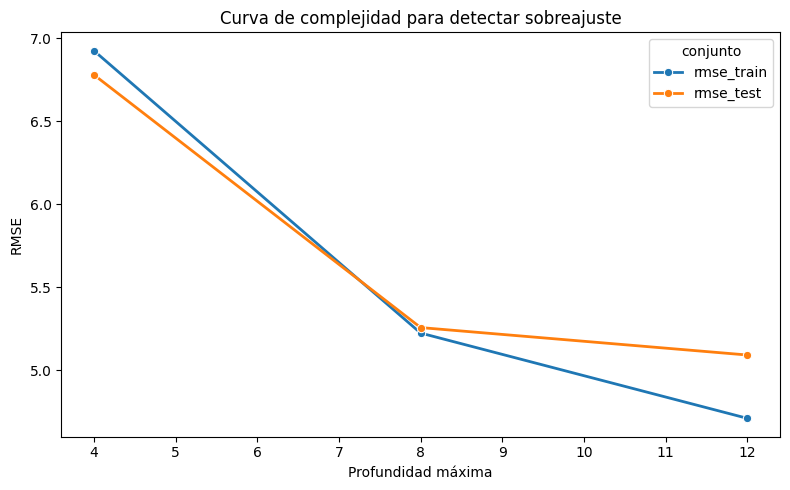

,maxDepth,rmse_train,rmse_test,fit_seconds
0,4,6.9263,6.7810,5.9439
1,8,5.2251,5.2582,13.6918
2,12,4.7113,5.0929,34.8236


In [52]:
complexity_long = complexity_df.melt(
    id_vars="maxDepth",
    value_vars=["rmse_train", "rmse_test"],
    var_name="conjunto",
    value_name="rmse",
)
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=complexity_long,
    x="maxDepth",
    y="rmse",
    hue="conjunto",
    marker="o",
    linewidth=2,
)
plt.title("Curva de complejidad para detectar sobreajuste")
plt.xlabel("Profundidad máxima")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

display(complexity_df.round(4))


**Interpretación del gráfico.** Al subir la profundidad de 4 a 8 el error baja de forma clara en train y test. De 8 a 12, train mejora más que test y el costo de entrenamiento aumenta, por lo que la ganancia adicional empieza a ser menos eficiente y puede acercarse a sobreajuste.


La siguiente gráfica muestra la importancia de variables del Random Forest, agregada por variable original para evitar interpretar columnas dummy por separado.


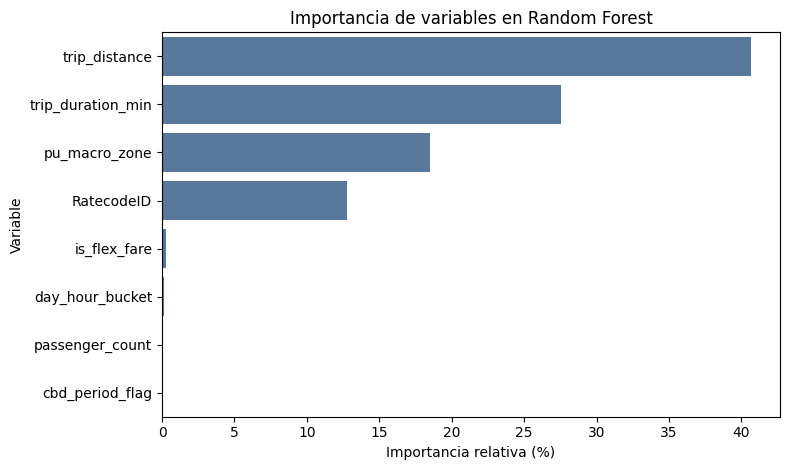

,variable,importance,importance_pct
6,trip_distance,0.4063,40.6280
7,trip_duration_min,0.2753,27.5309
5,pu_macro_zone,0.1851,18.5127
0,RatecodeID,0.1275,12.7466
3,is_flex_fare,0.0029,0.2922
2,day_hour_bucket,0.0016,0.1591
4,passenger_count,0.0009,0.0862
1,cbd_period_flag,0.0004,0.0443


In [53]:
feature_schema = best_pipeline_rf.transform(train_base_ml.limit(1)).schema["features"]
feature_attrs = []
for attr_group in feature_schema.metadata["ml_attr"]["attrs"].values():
    feature_attrs.extend(attr_group)
feature_attrs = sorted(feature_attrs, key=lambda attr: attr["idx"])

rf_feature_importances = best_pipeline_rf.stages[-1].featureImportances.toArray()
feature_importance_pdf = pd.DataFrame(
    {
        "feature": [attr["name"] for attr in feature_attrs],
        "importance": rf_feature_importances,
    }
)


def original_feature_name(feature_name):
    if feature_name in SUPERVISED_NUM_COLS:
        return feature_name
    for col_name in SUPERVISED_CAT_COLS:
        if feature_name.startswith(f"{col_name}_ohe"):
            return col_name
    return feature_name


feature_importance_pdf["variable"] = feature_importance_pdf["feature"].apply(
    original_feature_name
)
feature_importance_grouped_pdf = (
    feature_importance_pdf.groupby("variable", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)
feature_importance_grouped_pdf["importance_pct"] = (
    feature_importance_grouped_pdf["importance"]
    / feature_importance_grouped_pdf["importance"].sum()
    * 100
)

plt.figure(figsize=(8, 4.8))
sns.barplot(
    data=feature_importance_grouped_pdf,
    x="importance_pct",
    y="variable",
    color="#4C78A8",
)
plt.title("Importancia de variables en Random Forest")
plt.xlabel("Importancia relativa (%)")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

display(feature_importance_grouped_pdf.round(4))


**Interpretación del gráfico.** La importancia del Random Forest queda concentrada en variables operativas centrales: `trip_distance` aporta 40.63%, `trip_duration_min` 27.53%, `pu_macro_zone` 18.51% y `RatecodeID` 12.75%. En conjunto, distancia, duración, zona y régimen tarifario explican prácticamente toda la señal usada por el modelo. Esto es coherente con la lógica del negocio: la tarifa base depende sobre todo de recorrido, tiempo, origen y reglas tarifarias. La lectura no debe interpretarse como causalidad, sino como importancia interna del modelo para reducir error de predicción.


La siguiente gráfica compara la distribución de tarifa real contra tarifa predicha por Random Forest.


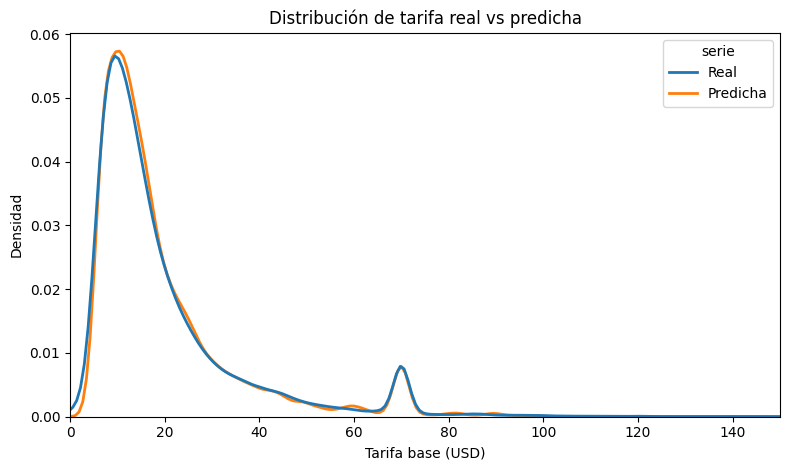

,fare_amount,prediction
mean,20.028299,20.0050
median,14.200000,14.4705
std,17.994301,16.8672


In [54]:
rf_diagnostic_fraction = min(1.0, 100_000 / n_test_base_ml)
rf_diagnostic_pdf = (
    pred_rf.select(TARGET, "prediction", "is_flex_fare")
    .sample(fraction=rf_diagnostic_fraction, seed=42)
    .toPandas()
)
rf_diagnostic_pdf["segmento"] = np.where(
    rf_diagnostic_pdf["is_flex_fare"] == 1, "Flex Fare", "Metered"
)

kde_pdf = rf_diagnostic_pdf.melt(
    value_vars=[TARGET, "prediction"], var_name="serie", value_name="tarifa"
)
kde_pdf["serie"] = kde_pdf["serie"].map({TARGET: "Real", "prediction": "Predicha"})
kde_plot_pdf = kde_pdf[kde_pdf["tarifa"].between(0, 150)]

plt.figure(figsize=(8, 4.8))
sns.kdeplot(data=kde_plot_pdf, x="tarifa", hue="serie", common_norm=False, linewidth=2)
plt.title("Distribución de tarifa real vs predicha")
plt.xlabel("Tarifa base (USD)")
plt.ylabel("Densidad")
plt.xlim(0, 150)
plt.tight_layout()
plt.show()

display(
    rf_diagnostic_pdf[[TARGET, "prediction"]].agg(["mean", "median", "std"]).round(4)
)


**Interpretación del gráfico.** La distribución predicha se parece mucho a la distribución real en el centro: la media real es 20.03 USD y la predicha 20.01 USD; la mediana real es 14.20 USD y la predicha 14.47 USD. Esto no sugiere sobreajuste por sí solo porque la comparación se hace sobre datos de prueba; más bien indica que el modelo reproduce bien la masa principal de tarifas. La señal de cautela está en la dispersión: la desviación estándar predicha es menor que la real, 16.87 contra 17.99, lo que sugiere suavizado de colas y posible menor precisión en tarifas altas o casos especiales.


La siguiente gráfica resume el error del modelo por rangos de tarifa real, separando la cola alta para no esconder viajes extremos en una sola categoría.


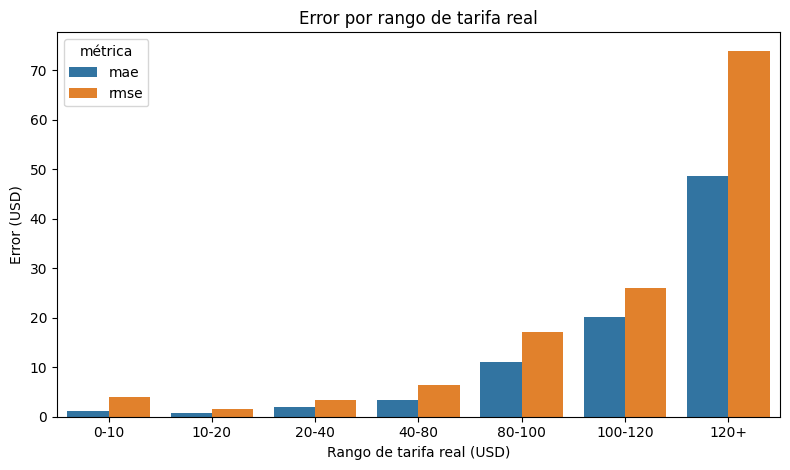

,rango_tarifa,n,mae,rmse
0,0-10,26121,1.1458,3.8970
1,10-20,42915,0.7618,1.5534
2,20-40,20563,2.0298,3.4502
3,40-80,9475,3.3883,6.4685
4,80-100,609,11.0326,17.1562
5,100-120,172,20.1770,25.9767
6,120+,195,48.6938,73.9522


In [55]:
fare_bins = [0, 10, 20, 40, 80, 100, 120, np.inf]
fare_labels = ["0-10", "10-20", "20-40", "40-80", "80-100", "100-120", "120+"]
rf_diagnostic_pdf["rango_tarifa"] = pd.cut(
    rf_diagnostic_pdf[TARGET],
    bins=fare_bins,
    labels=fare_labels,
    include_lowest=True,
    right=False,
)
rf_diagnostic_pdf["abs_error"] = (
    rf_diagnostic_pdf["prediction"] - rf_diagnostic_pdf[TARGET]
).abs()
rf_diagnostic_pdf["squared_error"] = (
    rf_diagnostic_pdf["prediction"] - rf_diagnostic_pdf[TARGET]
) ** 2

error_by_fare_bin_pdf = (
    rf_diagnostic_pdf.dropna(subset=["rango_tarifa"])
    .groupby("rango_tarifa", observed=False)
    .agg(
        n=(TARGET, "size"),
        mae=("abs_error", "mean"),
        rmse=("squared_error", lambda values: np.sqrt(values.mean())),
    )
    .reset_index()
)
error_by_fare_bin_long_pdf = error_by_fare_bin_pdf.melt(
    id_vars=["rango_tarifa", "n"],
    value_vars=["mae", "rmse"],
    var_name="métrica",
    value_name="error_usd",
)

plt.figure(figsize=(8, 4.8))
sns.barplot(
    data=error_by_fare_bin_long_pdf,
    x="rango_tarifa",
    y="error_usd",
    hue="métrica",
)
plt.title("Error por rango de tarifa real")
plt.xlabel("Rango de tarifa real (USD)")
plt.ylabel("Error (USD)")
plt.tight_layout()
plt.show()

display(error_by_fare_bin_pdf.round(4))


**Interpretación del gráfico.** El error no crece de forma uniforme: en tarifas de 10 a 20 USD el MAE es 0.76 y el RMSE 1.55, mientras que en 40 a 80 USD sube a MAE 3.39 y RMSE 6.47. La cola alta concentra la principal limitación del modelo: 80-100 USD llega a RMSE 17.16, 100-120 USD a 25.98 y 120+ a 73.95, aunque esos grupos tienen muchos menos registros que los rangos centrales. El gráfico sí aporta valor porque muestra que el modelo es confiable para la masa principal de viajes, pero debe usarse con cautela en tarifas extremas, probablemente asociadas a viajes largos, reglas especiales o casos atípicos.


La siguiente gráfica compara tarifa real contra predicha y residuales contra predicción.


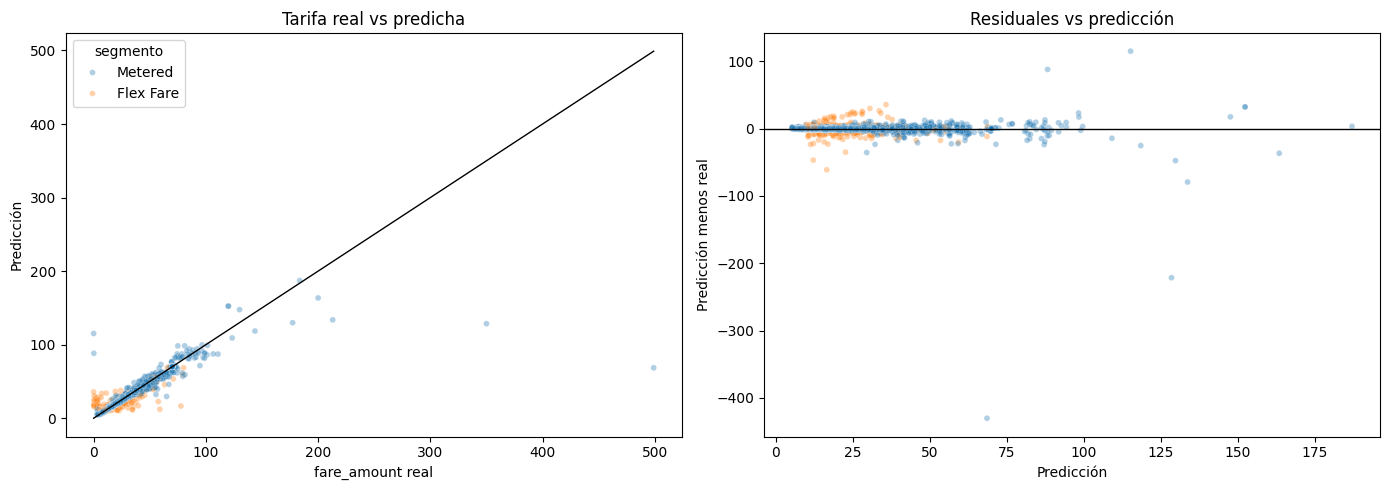

In [56]:
scatter_plot_pdf = scatter_pdf.copy()
scatter_plot_pdf["segmento"] = np.where(
    scatter_plot_pdf["is_flex_fare"] == 1, "Flex Fare", "Metered"
)
scatter_plot_pdf["residual"] = scatter_plot_pdf["prediction"] - scatter_plot_pdf[TARGET]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(
    data=scatter_plot_pdf,
    x=TARGET,
    y="prediction",
    hue="segmento",
    alpha=0.35,
    s=18,
    ax=ax[0],
)
min_val = min(scatter_plot_pdf[TARGET].min(), scatter_plot_pdf["prediction"].min())
max_val = max(scatter_plot_pdf[TARGET].max(), scatter_plot_pdf["prediction"].max())
ax[0].plot([min_val, max_val], [min_val, max_val], color="black", linewidth=1)
ax[0].set_title("Tarifa real vs predicha")
ax[0].set_xlabel("fare_amount real")
ax[0].set_ylabel("Predicción")

sns.scatterplot(
    data=scatter_plot_pdf,
    x="prediction",
    y="residual",
    hue="segmento",
    alpha=0.35,
    s=18,
    ax=ax[1],
    legend=False,
)
ax[1].axhline(0, color="black", linewidth=1)
ax[1].set_title("Residuales vs predicción")
ax[1].set_xlabel("Predicción")
ax[1].set_ylabel("Predicción menos real")
plt.tight_layout()
plt.show()


**Interpretación del gráfico.** La nube de predicción contra valor real sigue la diagonal general, lo que confirma que el modelo captura la estructura principal de la tarifa. Los residuales se concentran cerca de cero, pero aumentan en algunos rangos de tarifa, señal de casos especiales o segmentos con reglas tarifarias menos representadas por las variables del modelo.


La siguiente gráfica muestra RMSE por segmento tarifario y fold.


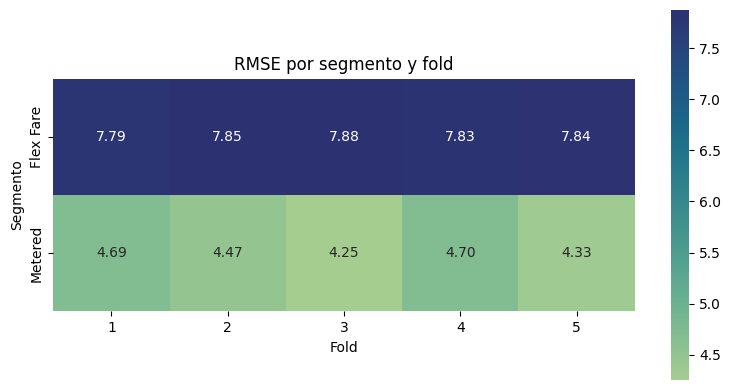

,fold,segmento,n,rmse
0,1,Metered,846844,4.6904
1,1,Flex Fare,149850,7.7888
2,2,Metered,846662,4.4665
3,2,Flex Fare,149848,7.8512
4,3,Metered,846699,4.2505
5,3,Flex Fare,149842,7.8768
6,4,Metered,846602,4.7025
7,4,Flex Fare,149837,7.8260
8,5,Metered,846458,4.3301
9,5,Flex Fare,149833,7.8362


In [57]:
seg_pivot = seg_df.pivot(index="segmento", columns="fold", values="rmse")
plt.figure(figsize=(8, 4))
sns.heatmap(seg_pivot, annot=True, fmt=".2f", cmap="crest", square=True)
plt.title("RMSE por segmento y fold")
plt.xlabel("Fold")
plt.ylabel("Segmento")
plt.tight_layout()
plt.show()

display(seg_df.round(4))


**Interpretación del gráfico.** El heatmap por segmento muestra una diferencia clara: Metered mantiene errores menores y más estables, mientras Flex Fare concentra RMSE alto en todos los folds. Esta brecha es importante para negocio porque el modelo es más confiable para viajes medidos por taxímetro que para esquemas flexibles.


**Lectura de la sección.** Los resultados supervisados son consistentes con el holdout y con la validación cruzada. El error se mantiene alrededor de 5 USD de RMSE y 1.6 USD de MAE en test, con variabilidad baja entre folds. La importancia de variables confirma una lógica operativa defendible: distancia, duración, zona de origen y régimen tarifario concentran la señal del Random Forest. La distribución real y predicha también queda bien alineada en el centro, con medias prácticamente iguales, pero la desviación estándar predicha es menor, lo que anticipa suavizado de colas. El análisis por rangos confirma esa limitación: el modelo funciona mejor en tarifas bajas y medias, y pierde precisión en tarifas superiores a 80 USD, especialmente en 120+ USD. Por segmento, Flex Fare conserva errores más altos que Metered, por lo que el uso del modelo debe reportarse con mayor confianza para viajes medidos por taxímetro y con cautela para tarifas flexibles o extremas.


## 9.2 Resultados del track no supervisado

Las siguientes gráficas revisan estabilidad de silhouette, balance de clusters y perfiles de arquetipos.


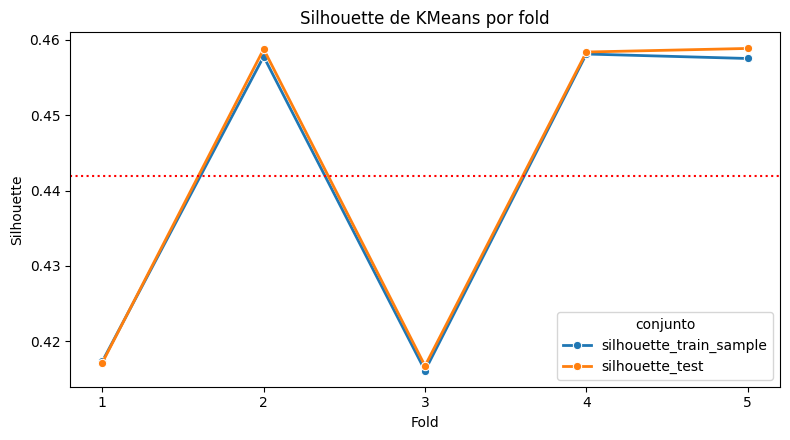

,fold,silhouette_train_sample,silhouette_test,fit_seconds,n_train_sample,n_test,min_cluster_fraction_test,max_cluster_fraction_test
0,1,0.4173,0.4172,12.7866,499473,996694,0.0562,0.5644
1,2,0.4578,0.4587,12.0188,499518,996510,0.0507,0.6563
2,3,0.4161,0.4168,11.8000,498564,996541,0.0566,0.5635
3,4,0.4581,0.4584,11.9555,501454,996439,0.0499,0.6572
4,5,0.4575,0.4588,11.7403,499755,996291,0.0503,0.6566


In [58]:
cluster_silhouette_long = cluster_cv_df.melt(
    id_vars="fold",
    value_vars=["silhouette_train_sample", "silhouette_test"],
    var_name="conjunto",
    value_name="silhouette",
)
plt.figure(figsize=(8, 4.5))
sns.lineplot(
    data=cluster_silhouette_long,
    x="fold",
    y="silhouette",
    hue="conjunto",
    marker="o",
    linewidth=2,
)
plt.axhline(
    cluster_cv_df["silhouette_test"].mean(),
    color="red",
    linestyle=":",
    linewidth=1.5,
    label="Media test",
)
plt.title("Silhouette de KMeans por fold")
plt.xlabel("Fold")
plt.ylabel("Silhouette")
plt.xticks(sorted(cluster_cv_df["fold"].unique()))
plt.tight_layout()
plt.show()

display(cluster_cv_df.round(4))


**Interpretación del gráfico.** El silhouette se mantiene positivo en todos los folds y fluctúa en un rango moderado. La solución no supervisada no es perfecta, pero sí muestra separación suficiente y repetible para describir arquetipos operativos en vez de producir grupos aleatorios.


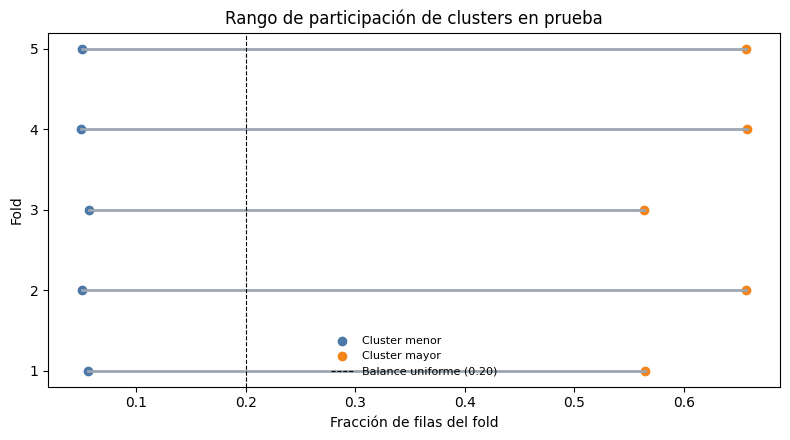

,fold,min_fraction,max_fraction
0,1,0.0562,0.5644
1,2,0.0507,0.6563
2,3,0.0566,0.5635
3,4,0.0499,0.6572
4,5,0.0503,0.6566


In [59]:
cluster_balance_summary = (
    cluster_balance_df.groupby("fold")
    .agg(
        min_fraction=("fraction", "min"),
        max_fraction=("fraction", "max"),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4.5))
for _, row in cluster_balance_summary.iterrows():
    ax.plot(
        [row["min_fraction"], row["max_fraction"]],
        [row["fold"], row["fold"]],
        color="#9AA6B2",
        linewidth=2,
    )
ax.scatter(
    cluster_balance_summary["min_fraction"],
    cluster_balance_summary["fold"],
    color="#4C78A8",
    label="Cluster menor",
)
ax.scatter(
    cluster_balance_summary["max_fraction"],
    cluster_balance_summary["fold"],
    color="#F58518",
    label="Cluster mayor",
)
ax.axvline(
    0.20, color="black", linestyle="--", linewidth=0.8, label="Balance uniforme (0.20)"
)
ax.set_title("Rango de participación de clusters en prueba")
ax.set_xlabel("Fracción de filas del fold")
ax.set_ylabel("Fold")
ax.set_yticks(sorted(cluster_balance_summary["fold"].unique()))
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

display(cluster_balance_summary.round(4))


**Interpretación del gráfico.** La proporción del cluster dominante se mantiene por debajo de un colapso total y los clusters pequeños siguen presentes en cada fold. Esto respalda que `k=5` produce una segmentación útil: hay un arquetipo urbano mayoritario, pero también patrones diferenciados de aeropuerto, viajes medianos, Flex y multipasajero.


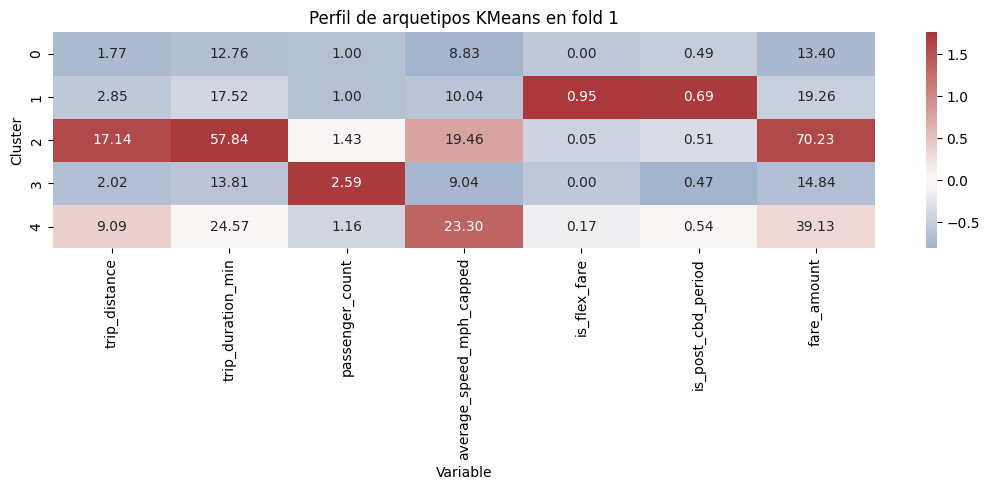

,cluster,n,trip_distance,trip_duration_min,passenger_count,average_speed_mph_capped,is_flex_fare,is_post_cbd_period,fare_amount
0,0,562568,1.7709,12.7625,1.0000,8.8343,0.0000,0.4935,13.4034
1,1,138699,2.8474,17.5183,1.0000,10.0393,0.9478,0.6904,19.2636
2,2,55985,17.1398,57.8370,1.4312,19.4590,0.0531,0.5075,70.2277
3,3,147144,2.0207,13.8122,2.5893,9.0369,0.0000,0.4674,14.8374
4,4,92298,9.0917,24.5731,1.1571,23.2975,0.1670,0.5352,39.1260


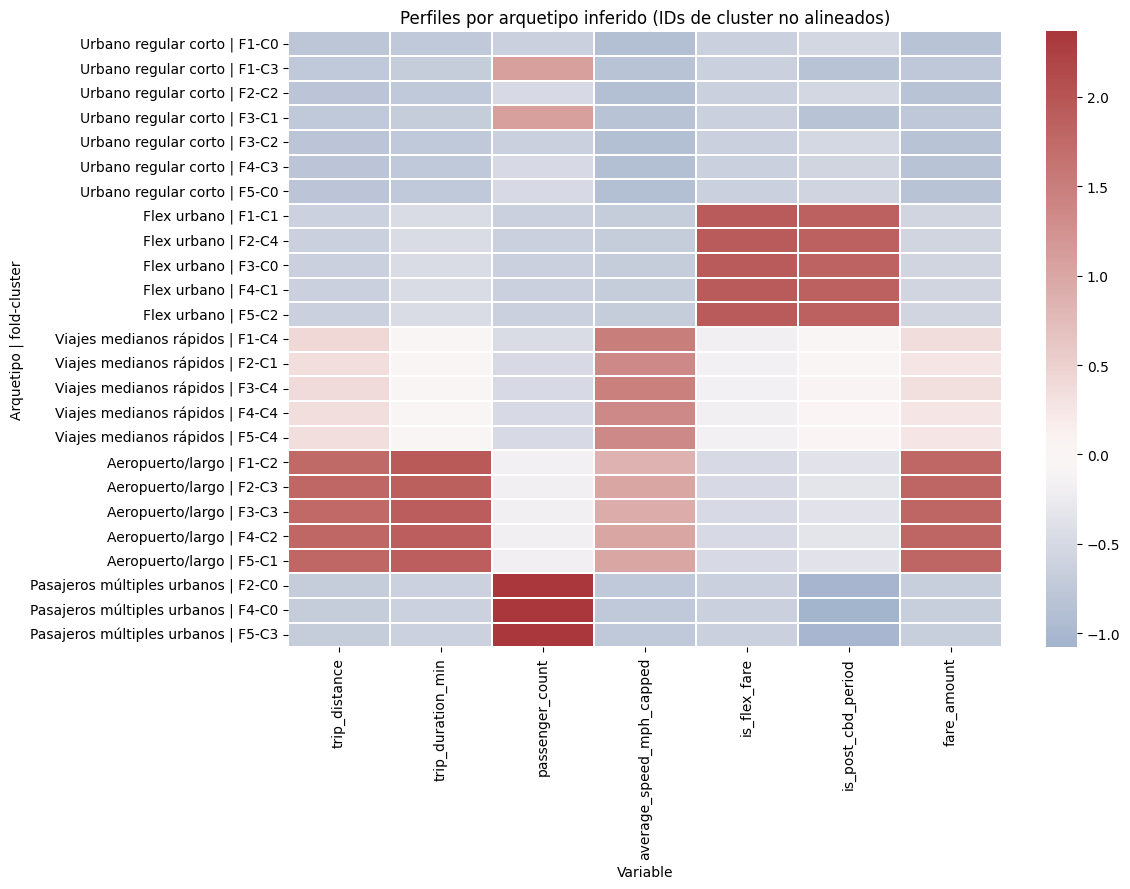

,fold,cluster,arquetipo_inferido,n,trip_distance,trip_duration_min,passenger_count,average_speed_mph_capped,is_flex_fare,fare_amount
0,1,0,Urbano regular corto,562568,1.7709,12.7625,1.0000,8.8343,0.0000,13.4034
1,1,3,Urbano regular corto,147144,2.0207,13.8122,2.5893,9.0369,0.0000,14.8374
2,2,2,Urbano regular corto,654057,1.7570,12.7893,1.1464,8.7737,0.0000,13.4069
3,3,1,Urbano regular corto,146319,2.0199,13.8070,2.5913,9.0368,0.0000,14.8573
4,3,2,Urbano regular corto,561563,1.7626,12.7458,1.0000,8.8158,0.0000,13.3760
5,4,3,Urbano regular corto,654883,1.7560,12.7804,1.1461,8.7699,0.0000,13.4020
6,5,0,Urbano regular corto,654200,1.7554,12.7776,1.1467,8.7735,0.0000,13.3988
7,1,1,Flex urbano,138699,2.8474,17.5183,1.0000,10.0393,0.9478,19.2636
8,2,4,Flex urbano,137519,2.8108,17.4756,1.0001,9.9547,0.9475,19.1847
9,3,0,Flex urbano,137718,2.8249,17.4811,1.0000,9.9827,0.9486,19.2057


In [60]:
profile_cols = [
    "trip_distance",
    "trip_duration_min",
    "passenger_count",
    "average_speed_mph_capped",
    "is_flex_fare",
    "is_post_cbd_period",
    TARGET,
]
profile_for_heatmap = cluster_profile_pdf.set_index("cluster")[profile_cols].astype(
    float
)
profile_std = profile_for_heatmap.std(axis=0).replace(0, np.nan)
profile_z = (
    (profile_for_heatmap - profile_for_heatmap.mean(axis=0)) / profile_std
).fillna(0)

plt.figure(figsize=(11, 5))
sns.heatmap(
    profile_z, annot=profile_for_heatmap.round(2), fmt=".2f", cmap="vlag", center=0
)
plt.title("Perfil de arquetipos KMeans en fold 1")
plt.xlabel("Variable")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

display(cluster_profile_pdf.round(4))


def infer_archetype(row):
    if row["is_flex_fare"] >= 0.80:
        return "Flex urbano"
    if row["trip_distance"] >= 12 and row[TARGET] >= 50:
        return "Aeropuerto/largo"
    if row["passenger_count"] >= 3:
        return "Pasajeros múltiples urbanos"
    if row["trip_distance"] >= 7 and row["average_speed_mph_capped"] >= 18:
        return "Viajes medianos rápidos"
    return "Urbano regular corto"


archetype_order = {
    "Urbano regular corto": 0,
    "Flex urbano": 1,
    "Viajes medianos rápidos": 2,
    "Aeropuerto/largo": 3,
    "Pasajeros múltiples urbanos": 4,
}

profile_all_plot = cluster_profile_all_df.copy()
profile_all_plot["arquetipo_inferido"] = profile_all_plot.apply(infer_archetype, axis=1)
profile_all_plot["orden_arquetipo"] = profile_all_plot["arquetipo_inferido"].map(
    archetype_order
)
profile_all_plot["fold_cluster"] = profile_all_plot.apply(
    lambda row: f"{row['arquetipo_inferido']} | F{int(row['fold'])}-C{int(row['cluster'])}",
    axis=1,
)
profile_all_plot = profile_all_plot.sort_values(
    ["orden_arquetipo", "fold", "cluster"]
).reset_index(drop=True)

archetype_map_df = profile_all_plot[
    [
        "fold",
        "cluster",
        "arquetipo_inferido",
        "n",
        "trip_distance",
        "trip_duration_min",
        "passenger_count",
        "average_speed_mph_capped",
        "is_flex_fare",
        "fare_amount",
    ]
].copy()

profile_all_values = profile_all_plot.set_index("fold_cluster")[profile_cols].astype(
    float
)
profile_all_std = profile_all_values.std(axis=0).replace(0, np.nan)
profile_all_z = (
    (profile_all_values - profile_all_values.mean(axis=0)) / profile_all_std
).fillna(0)

plt.figure(figsize=(12, 9))
sns.heatmap(profile_all_z, cmap="vlag", center=0, linewidths=0.25, linecolor="white")
plt.title("Perfiles por arquetipo inferido (IDs de cluster no alineados)")
plt.xlabel("Variable")
plt.ylabel("Arquetipo | fold-cluster")
plt.tight_layout()
plt.show()

display(archetype_map_df.round(4))


**Interpretación del gráfico.** Los mapas de calor de perfiles muestran que los arquetipos tienen señales operativas distintas: distancia y duración altas para aeropuerto/largo, alta proporción Flex para Flex urbano, más pasajeros en el grupo multipasajero y recorridos cortos en el urbano regular. La recurrencia por fold confirma que la mayoría de perfiles son estables, aunque multipasajero es el más sensible.


**Lectura de la sección.** La solución no supervisada mantiene silhouette positiva en todos los folds y no colapsa en un único grupo: el cluster dominante se mueve alrededor de 56% a 66% según el fold, con clusters menores todavía presentes. Los arquetipos urbano regular corto, Flex urbano, viajes medianos rápidos y aeropuerto/largo aparecen de forma recurrente. El grupo de pasajeros múltiples urbanos es más sensible y no siempre queda como cluster separado, lo que debe leerse como un patrón existente pero menos estable que los demás.


<a id="seccion-10"></a>
# 10. Discusión y conclusiones

Este proyecto estudia la operación de Yellow Taxi en Nueva York a partir de millones de viajes registrados entre 2024 y 2025. El problema central no es únicamente predecir una tarifa, sino entender qué tan explicable es el cobro de un viaje usando información operativa disponible y si, dentro de ese volumen de datos, existen patrones recurrentes que permitan describir tipos de servicio. Desde una perspectiva de negocio, esto sirve para evaluar confiabilidad tarifaria, detectar segmentos con mayor incertidumbre y resumir la operación en grupos interpretables para análisis posteriores.

La metodología siguió una cadena completa de análisis de grandes volúmenes de datos. Primero se consolidaron los archivos públicos del TLC y se revisó la calidad del dataset crudo. Después se aplicaron reglas de limpieza para eliminar fechas fuera del periodo de estudio, montos negativos, distancias no plausibles y viajes temporalmente inconsistentes. Con la base depurada se construyeron variables operativas, se generó una muestra estratificada representativa y se validó que conservara la distribución de zonas, métodos de pago, horarios y distancias. Finalmente, el proyecto evaluó dos enfoques: aprendizaje supervisado para estimar tarifa base y aprendizaje no supervisado para identificar arquetipos de viaje.

Los resultados muestran que la tarifa base sí puede estimarse con buen desempeño cuando se usan variables operativas limpias y una partición representativa. Random Forest superó al modelo lineal y mantuvo estabilidad tanto en holdout como en validación cruzada, con errores bajos para la masa principal de viajes. La importancia de variables es coherente con la operación del servicio: distancia, duración, zona de origen y régimen tarifario concentran casi toda la señal del modelo. Sin embargo, el desempeño no es uniforme. Los viajes medidos por taxímetro son más predecibles que Flex Fare, y el error aumenta en tarifas altas, especialmente en la cola de 120 USD o más. Esta lectura no contradice el buen desempeño global: precisa dónde el modelo es confiable y dónde debe usarse con cautela.

El análisis no supervisado también aporta una lectura útil de la operación. KMeans con cinco clusters produjo grupos interpretables y más estables que GMM: viajes urbanos cortos, viajes Flex urbanos, viajes medianos rápidos, viajes largos o de aeropuerto y viajes urbanos con varios pasajeros. Estos arquetipos no sustituyen una segmentación oficial del servicio, pero ayudan a convertir millones de registros en perfiles operativos comprensibles. La mayoría de patrones aparece de forma recurrente entre folds; el segmento multipasajero es el menos estable y debe interpretarse con mayor cautela. Además, el arquetipo urbano regular concentra una parte importante de la operación, por lo que todavía mezcla mucha actividad normal de Manhattan.

Las limitaciones principales vienen de información que no está en el dataset. No se observan tráfico real, clima, eventos, demanda local, ruta exacta, disponibilidad de taxis, reglas internas de las aplicaciones ni razones específicas detrás de tarifas upfront. Esto afecta especialmente a Flex Fare, a viajes con tarifas extremas y a la separación fina de algunos arquetipos. También hay límites propios de la modelación: Random Forest tiende a suavizar la cola de tarifas y KMeans produce perfiles útiles, pero no clases verdaderas ni etiquetas oficiales.

Como trabajo futuro, convendría probar modelos específicos para Flex Fare o al menos calibraciones por régimen tarifario, incorporar variables externas de tráfico, clima o eventos, y hacer una validación temporal fuera de muestra cuando exista un periodo posterior completo y comparable. Para tarifas altas, sería útil estudiar la cola por separado con reglas de negocio o modelos robustos a extremos. Para el track no supervisado, una línea razonable sería refinar el arquetipo urbano regular con una segunda segmentación o con variables geográficas más detalladas, sin perder la interpretabilidad que hizo útil a KMeans.

En conjunto, el proyecto demuestra que una metodología reproducible de limpieza, muestreo estratificado, modelado y validación permite transformar un dataset masivo de viajes en evidencia accionable. Después de controlar calidad y representatividad, los datos explican una parte sustancial del comportamiento tarifario y revelan estructuras operativas útiles para entender el sistema Yellow Taxi, siempre con cautela en los segmentos donde la información disponible no captura toda la realidad del servicio.


<a id="seccion-11"></a>
# 11. Declaración de uso de inteligencia artificial

Google. (2026). *Gemini 3.5 Flash* [Modelo de lenguaje grande], utilizado para el proceso de aprendizaje del contenido de la semana y la validación de errores conceptuales y de código. https://deepmind.google/models/gemini/flash/
